In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import h5py
from astropy.timeseries import LombScargle

Procesando estrella 1/50: 00...


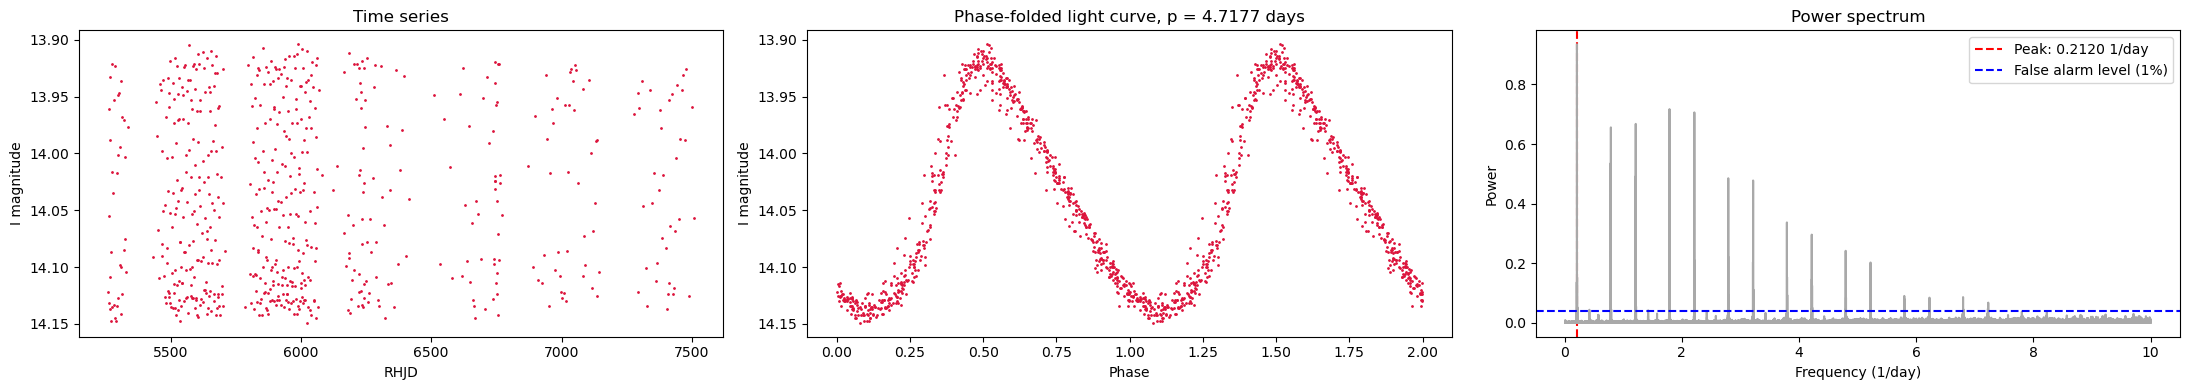

Procesando estrella 2/50: 01...


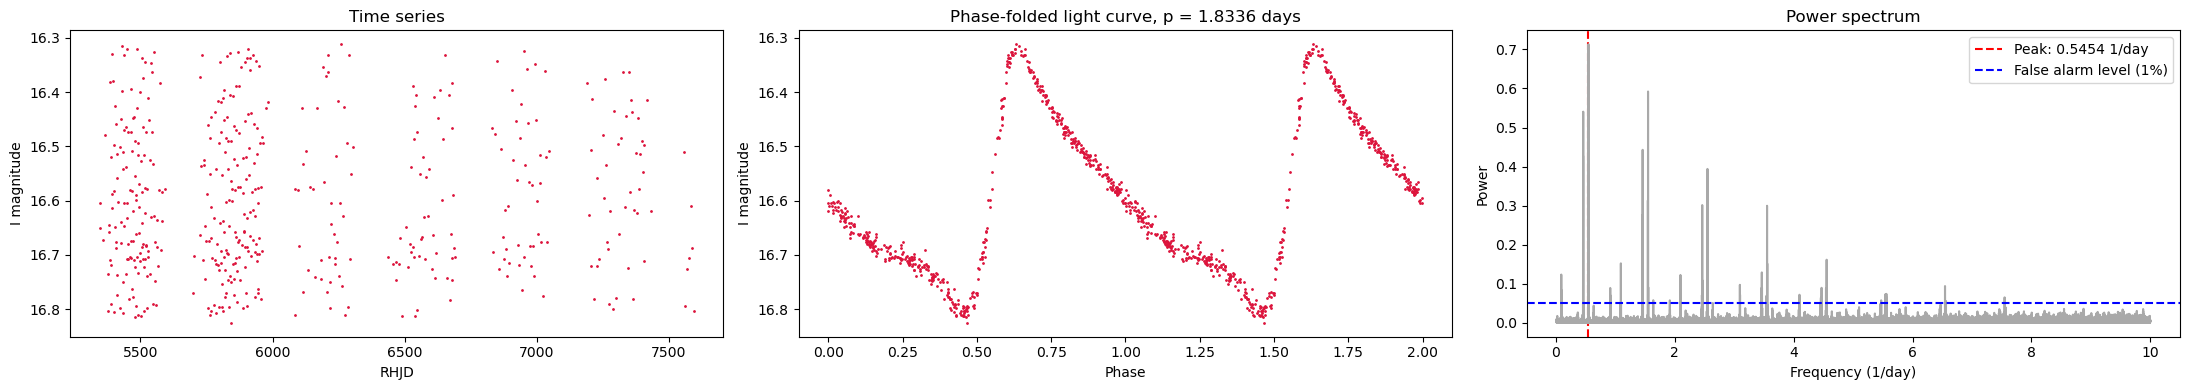

Procesando estrella 3/50: 02...


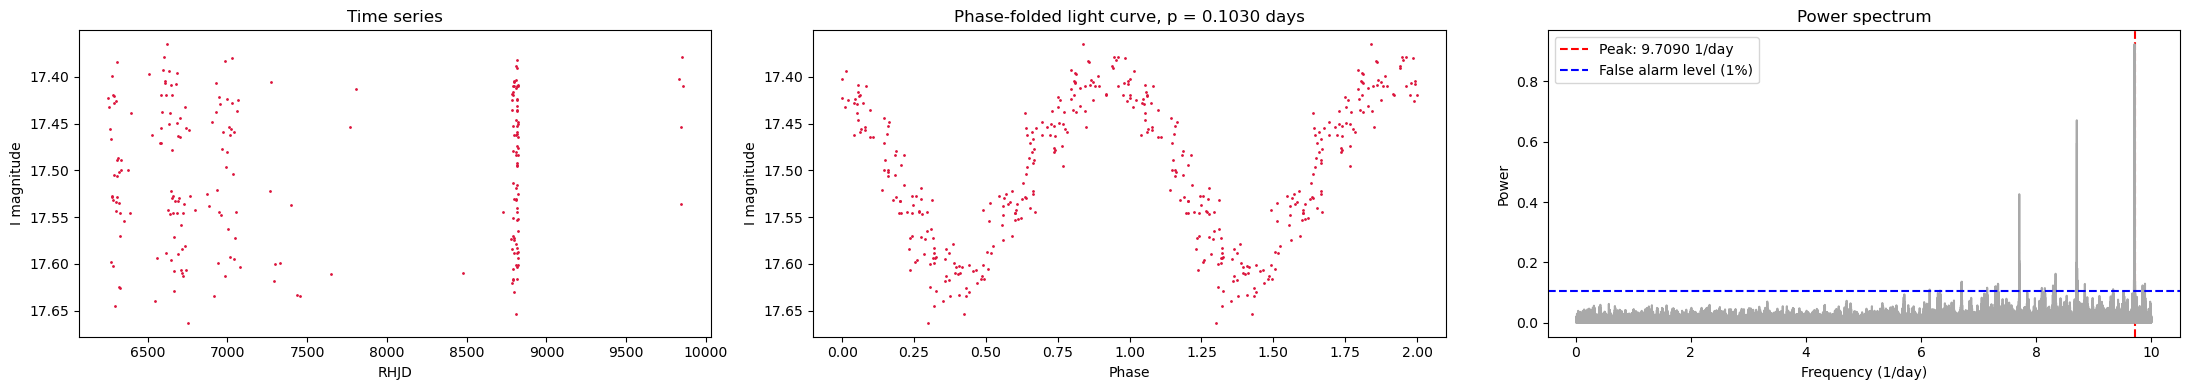

Procesando estrella 4/50: 03...


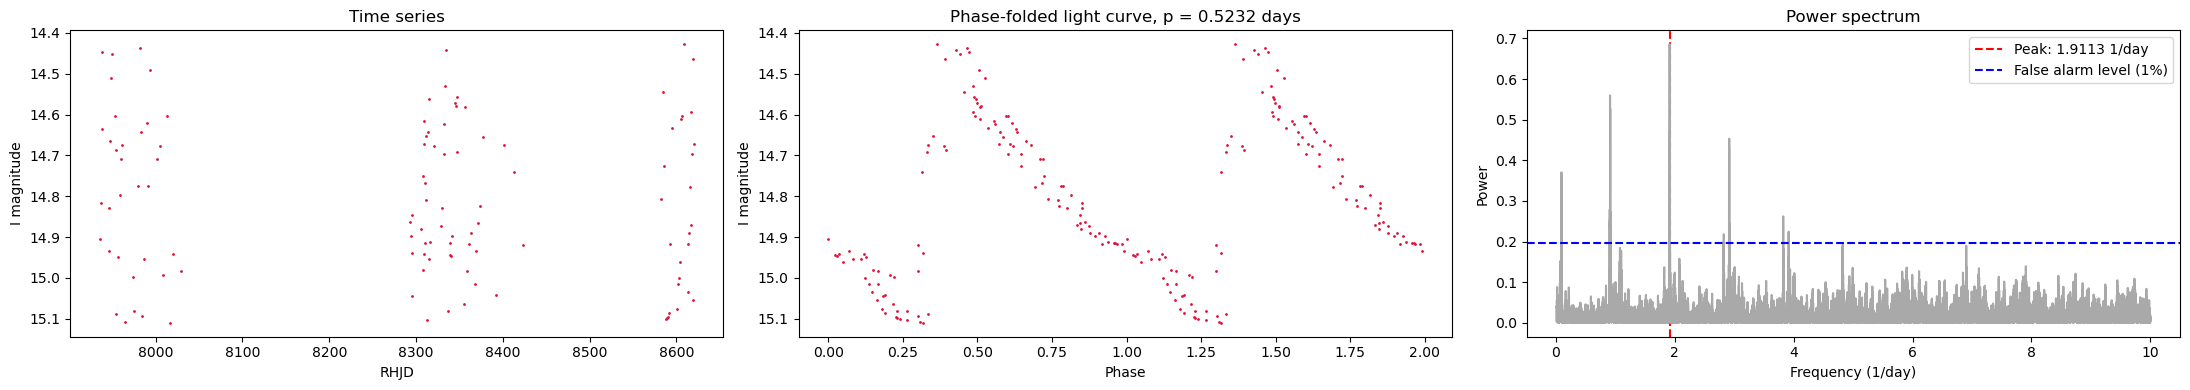

Procesando estrella 5/50: 04...


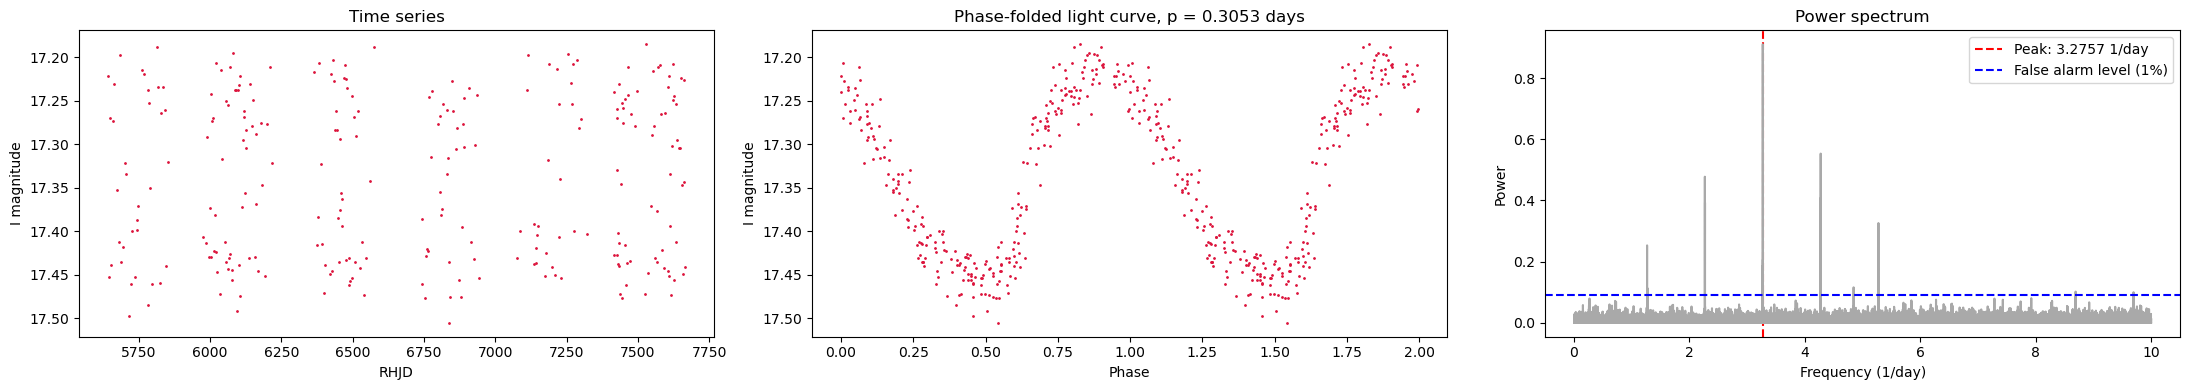

Procesando estrella 6/50: 05...


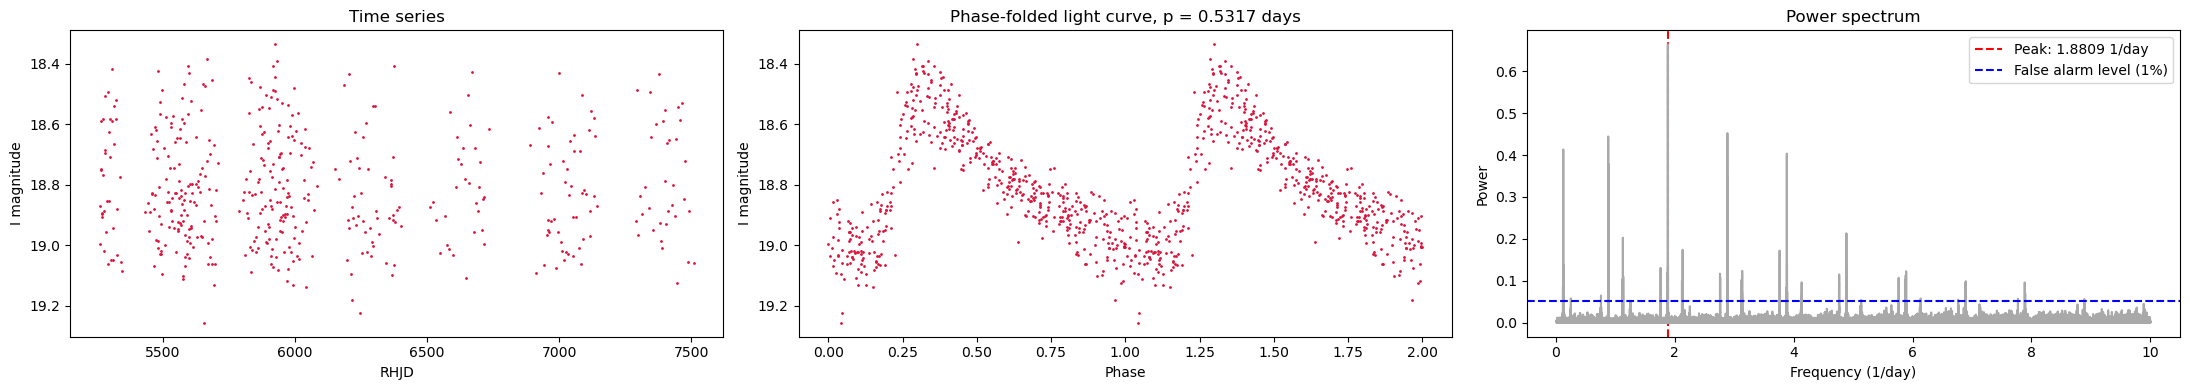

Procesando estrella 7/50: 06...


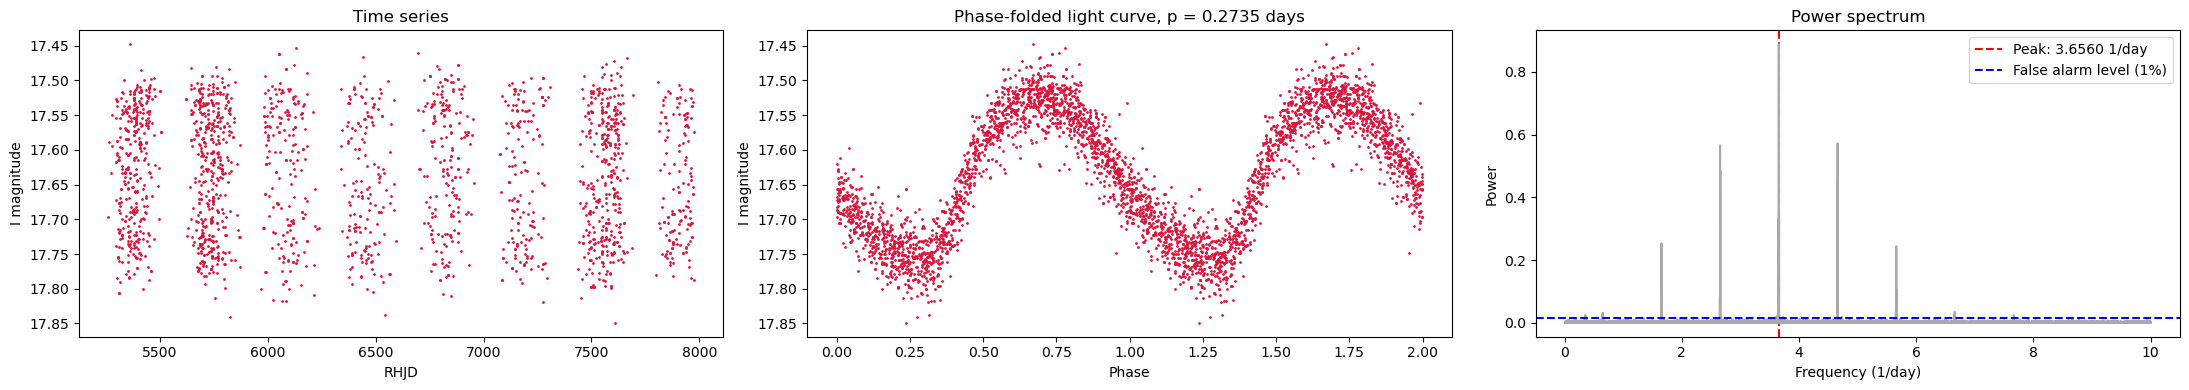

Procesando estrella 8/50: 07...


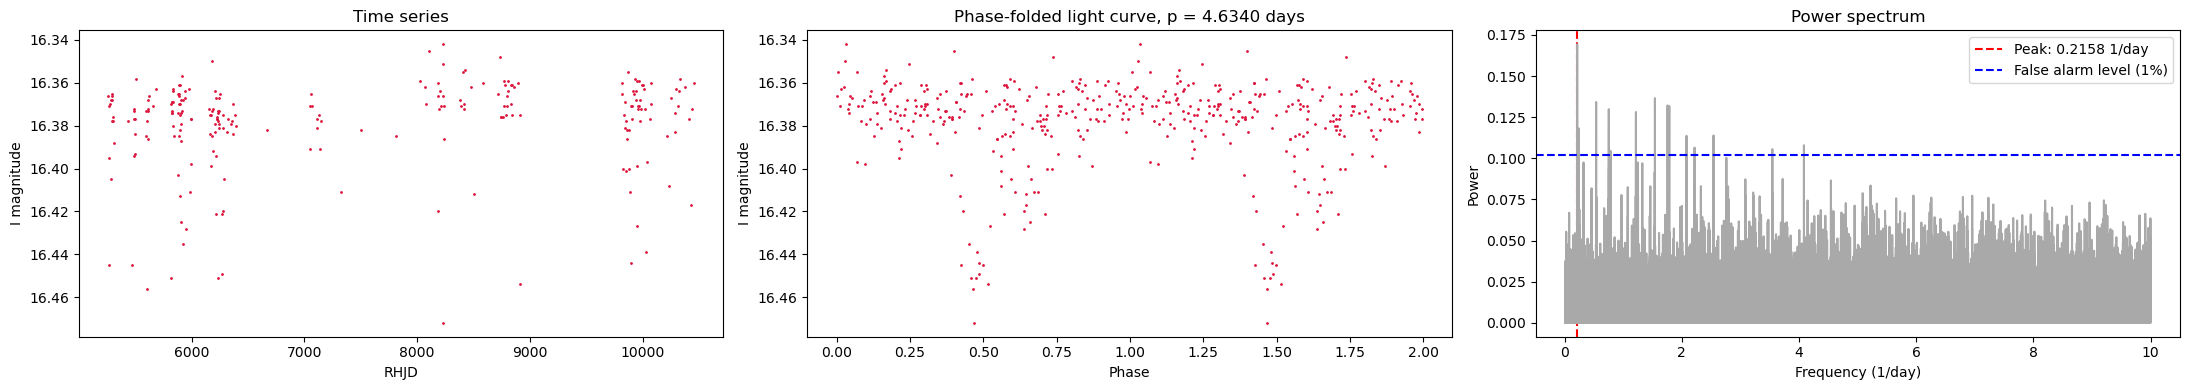

Procesando estrella 9/50: 08...


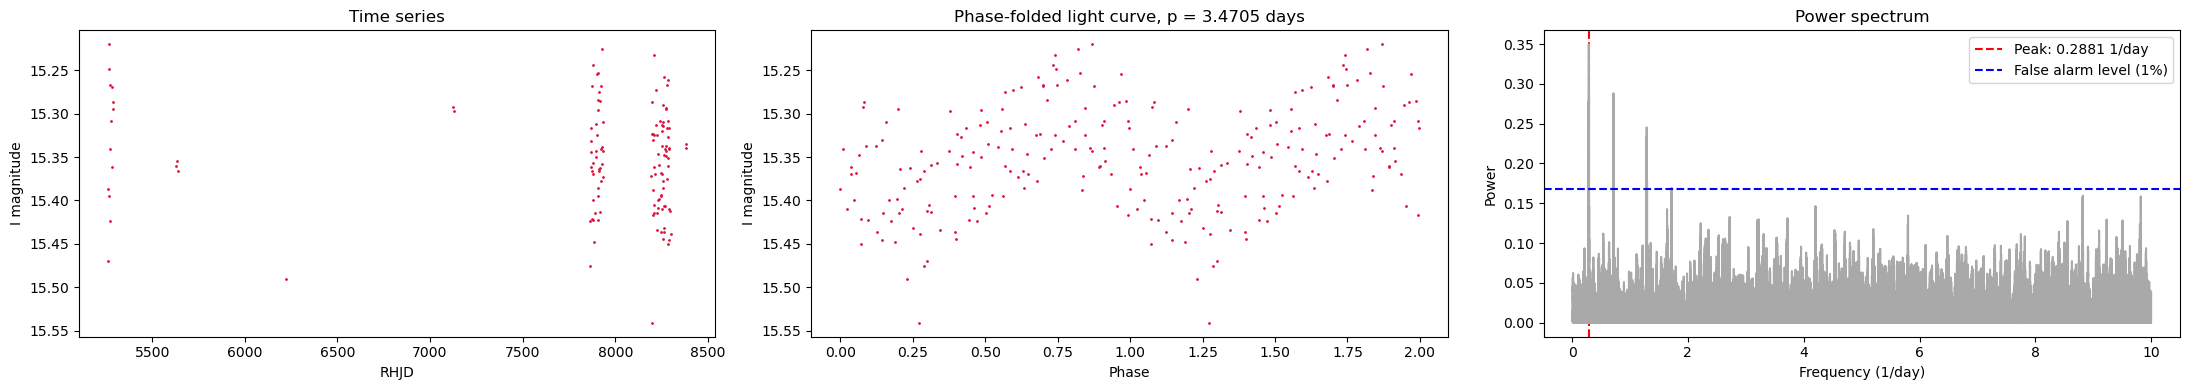

Procesando estrella 10/50: 09...


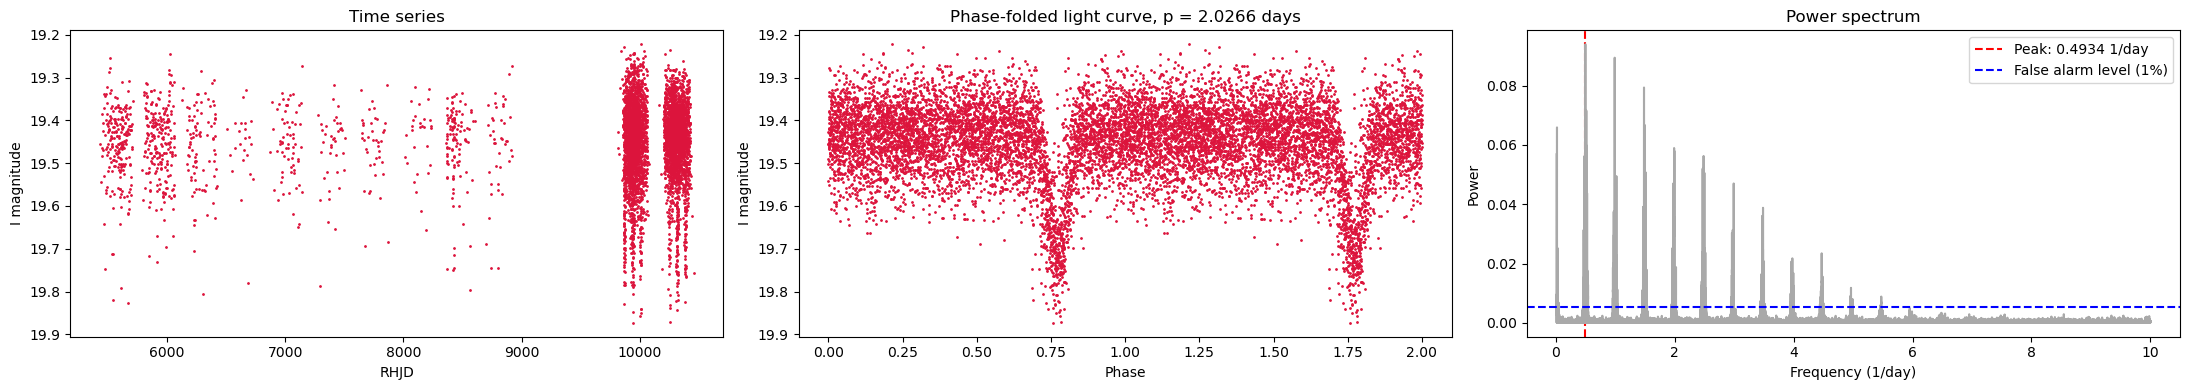

Procesando estrella 11/50: 0a...


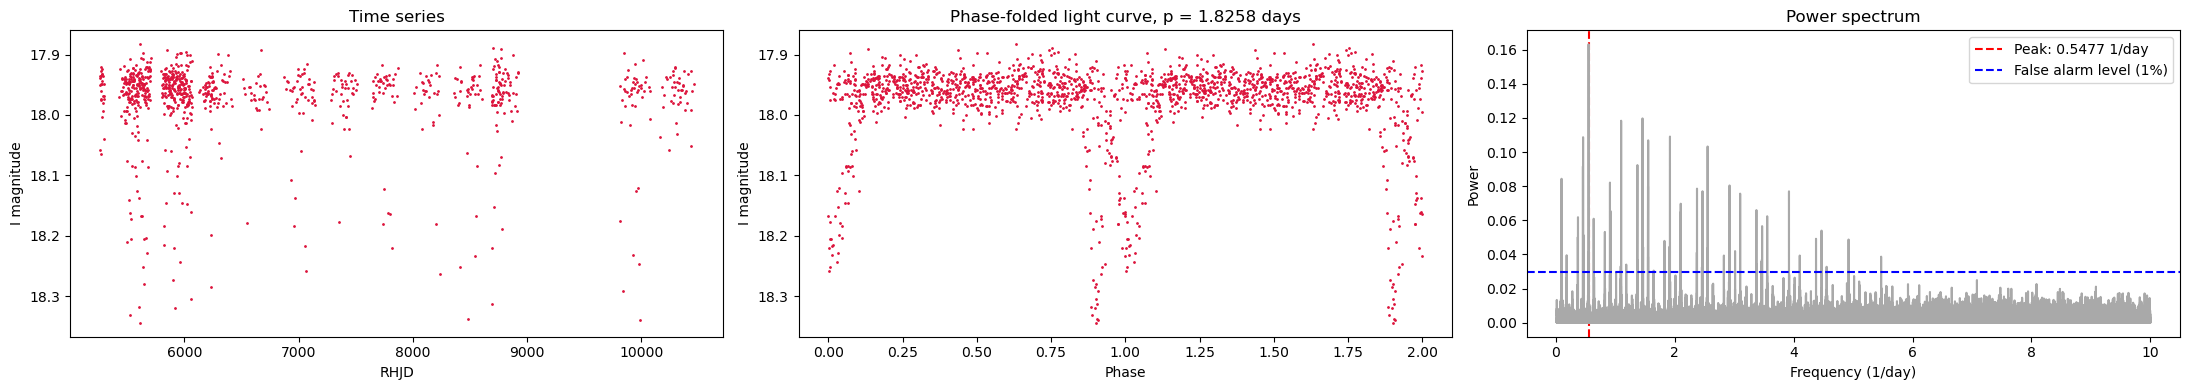

Procesando estrella 12/50: 0b...


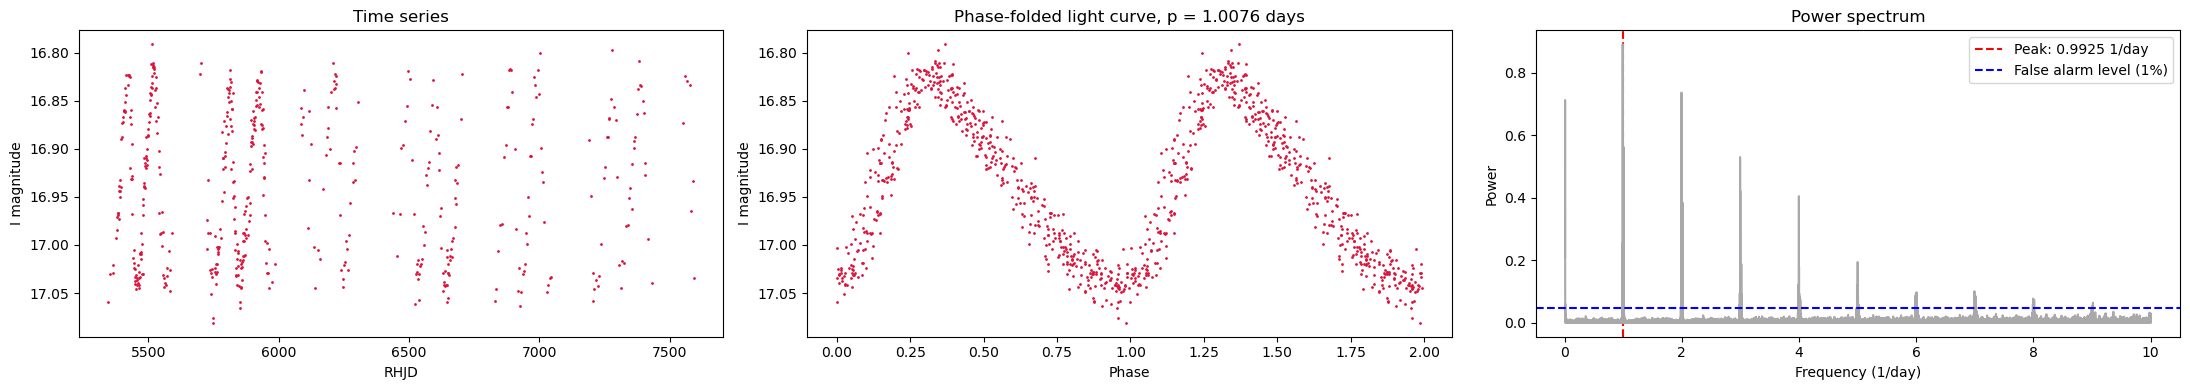

Procesando estrella 13/50: 0c...


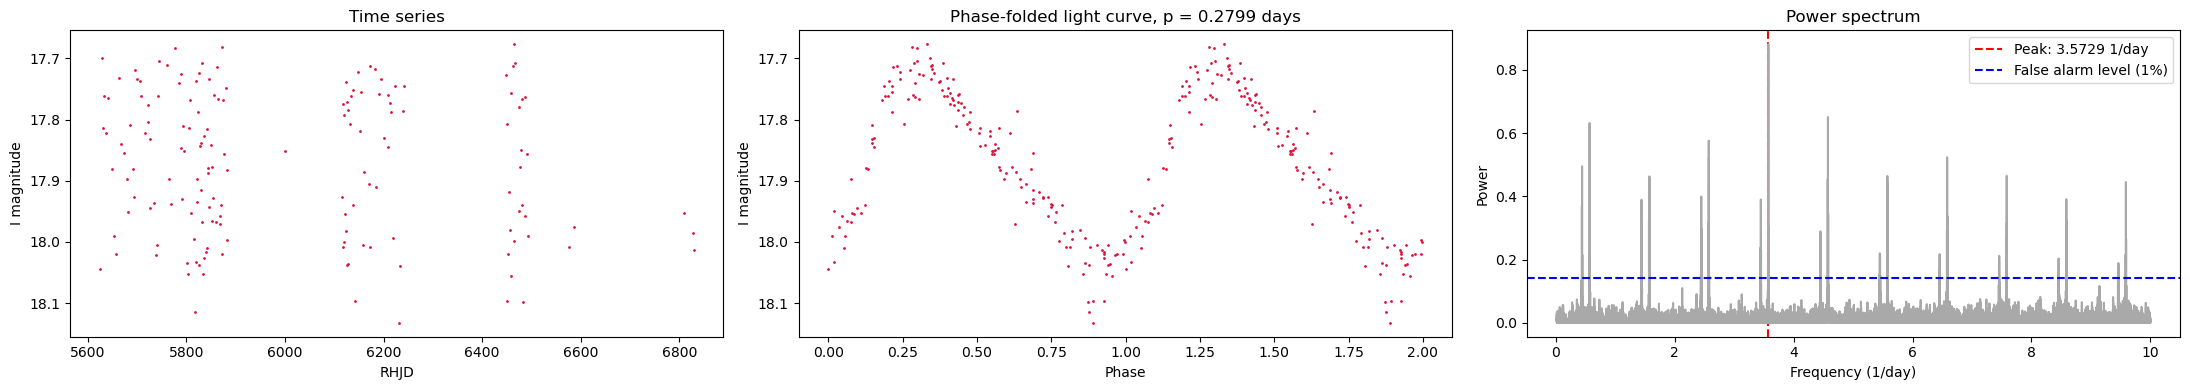

Procesando estrella 14/50: 0d...


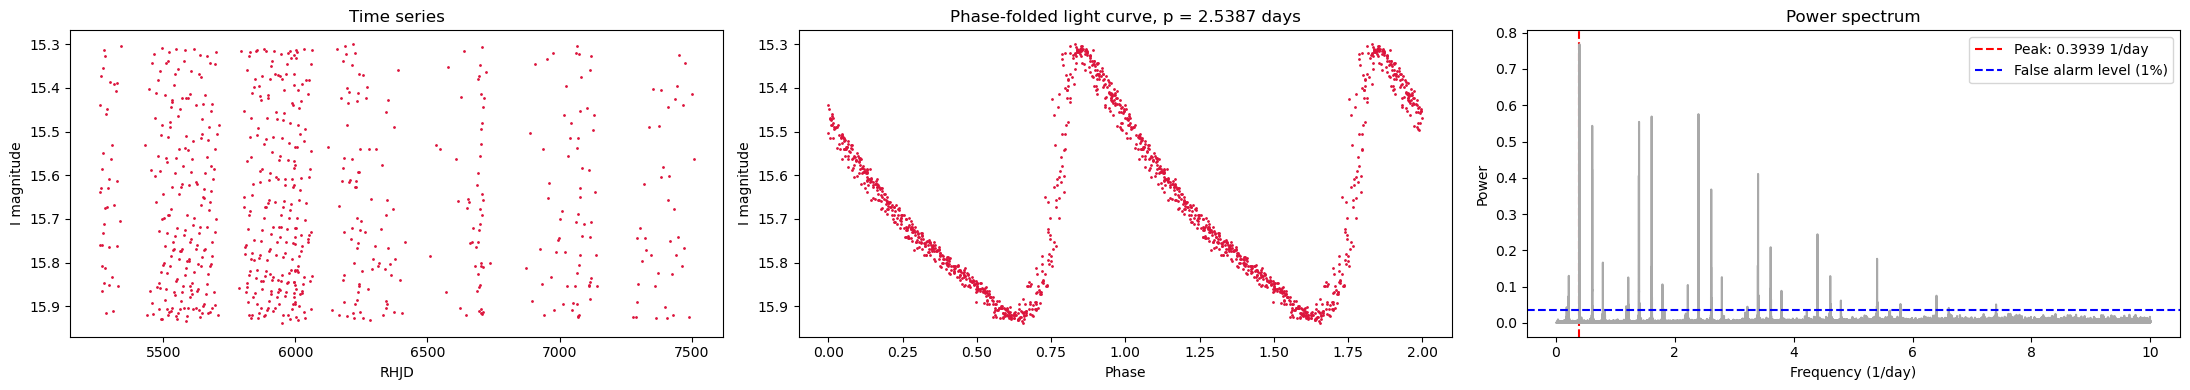

Procesando estrella 15/50: 0e...


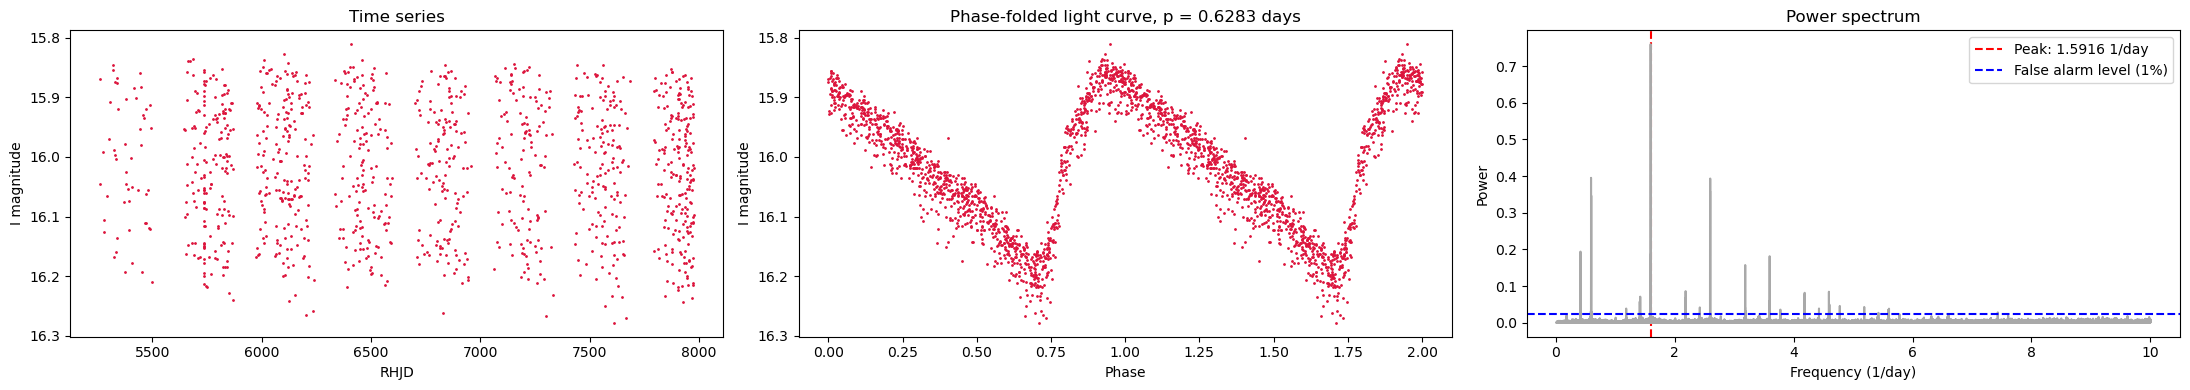

Procesando estrella 16/50: 0f...


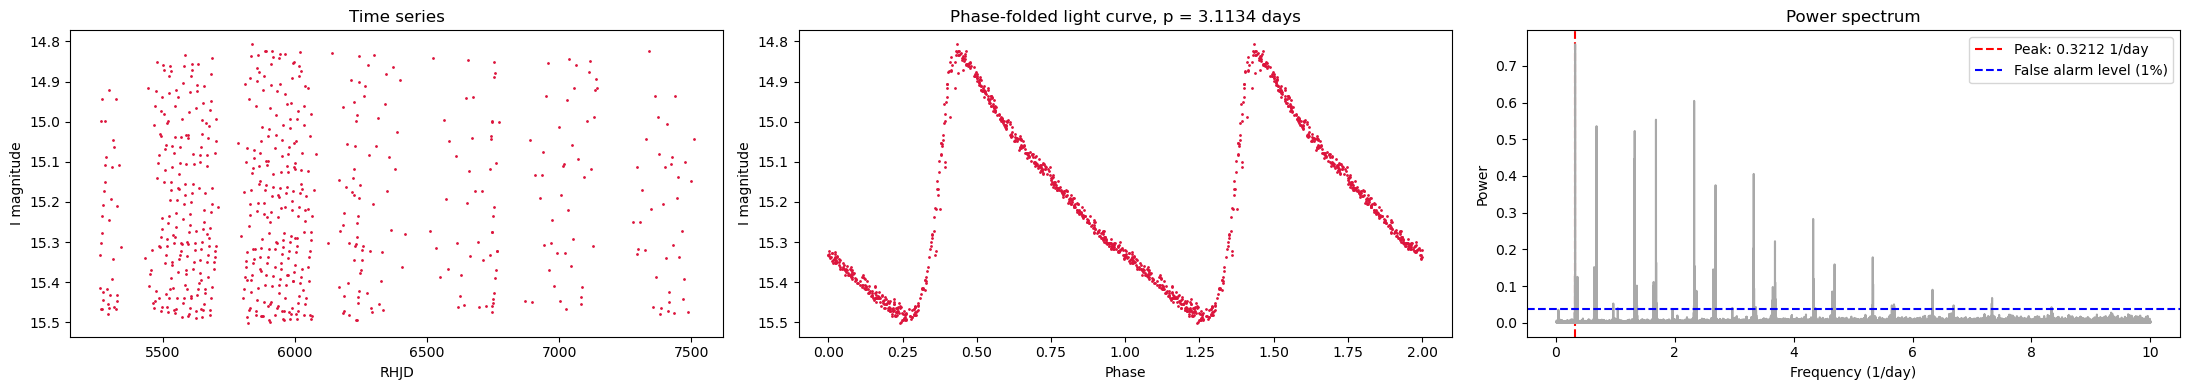

Procesando estrella 17/50: 10...


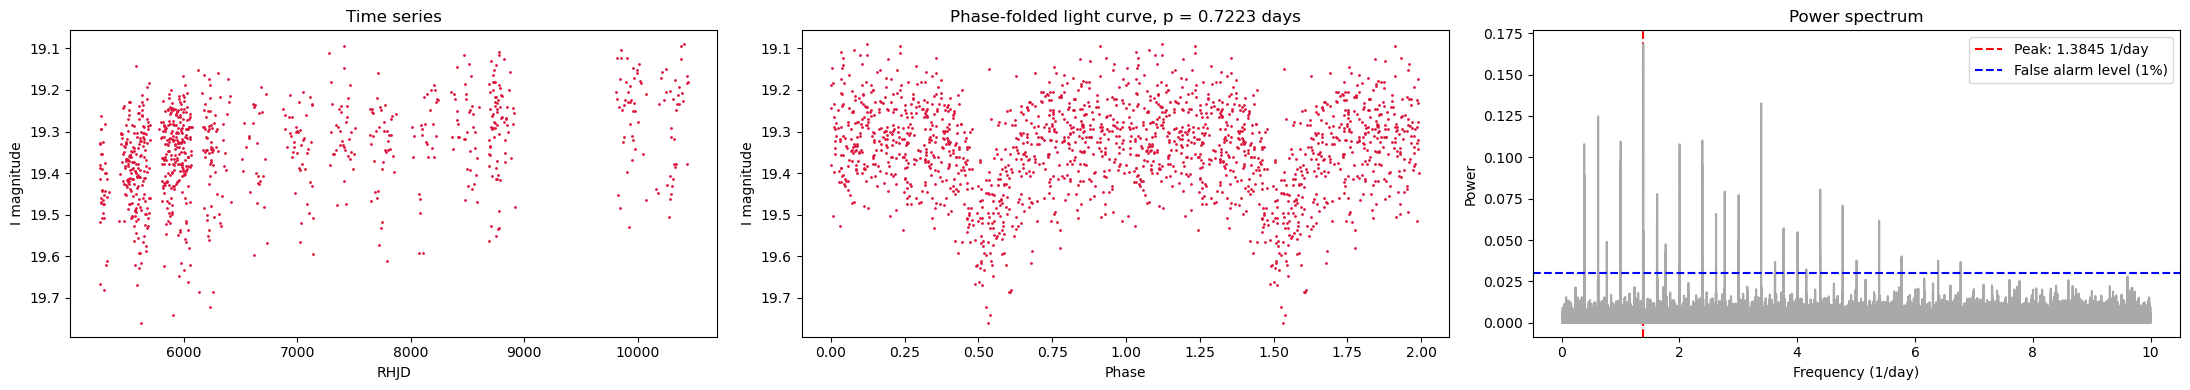

Procesando estrella 18/50: 11...


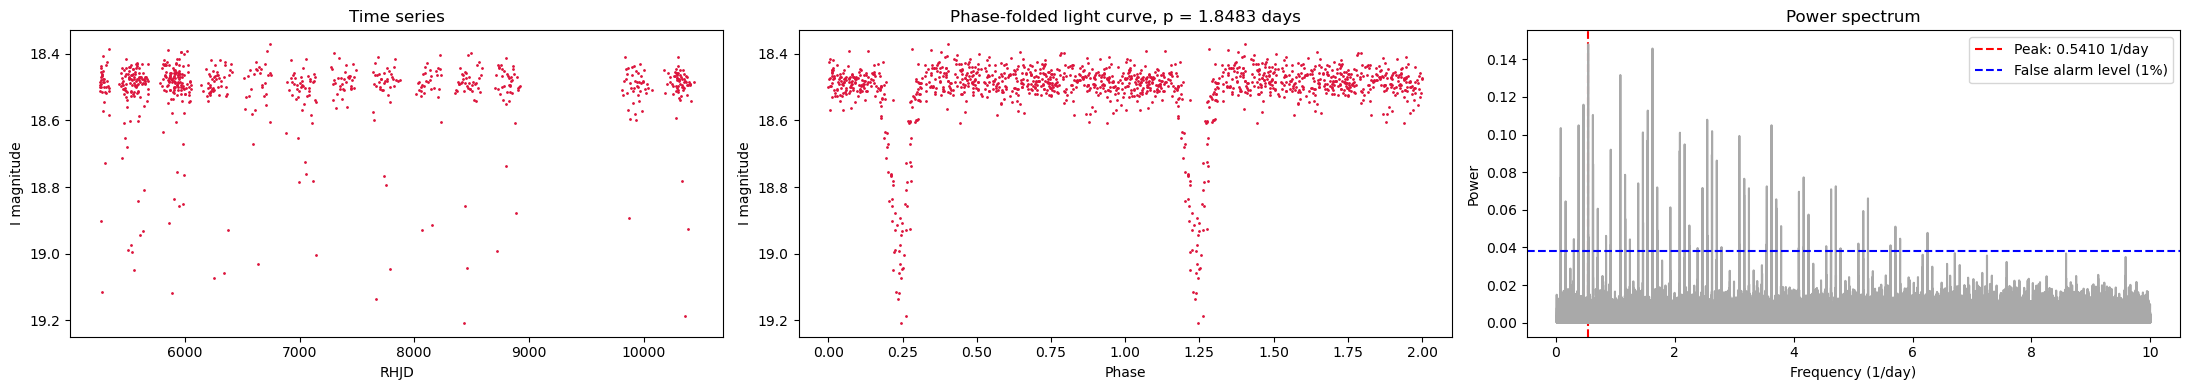

Procesando estrella 19/50: 12...


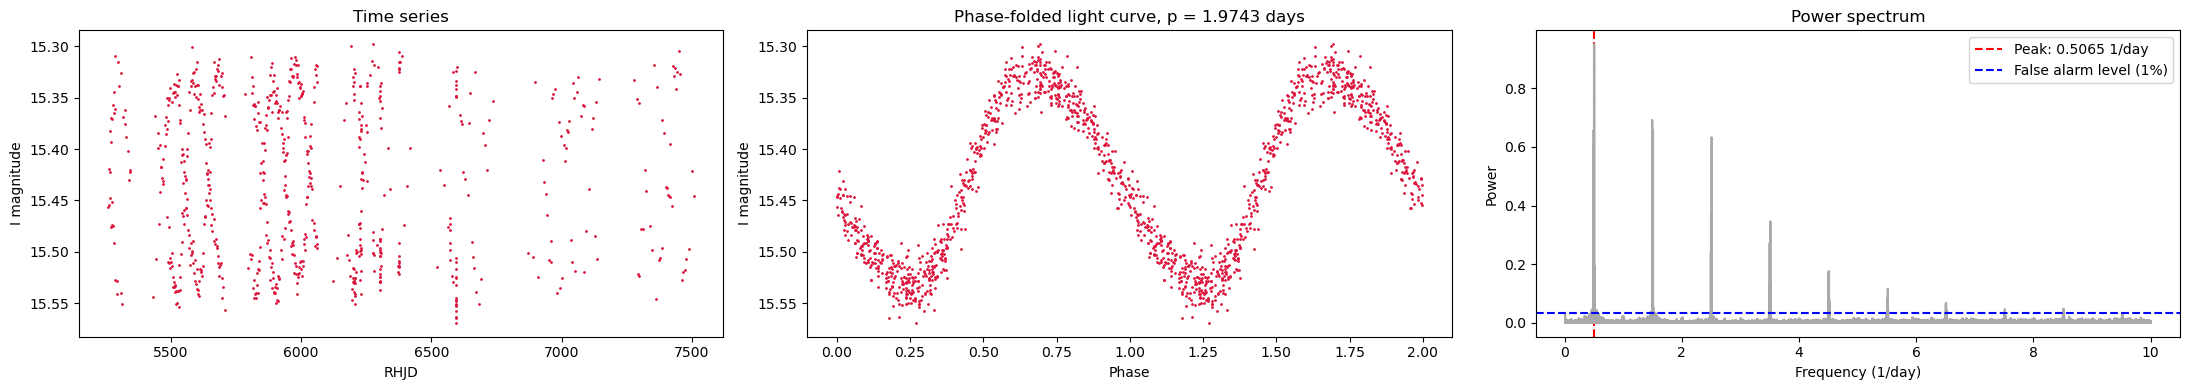

Procesando estrella 20/50: 13...


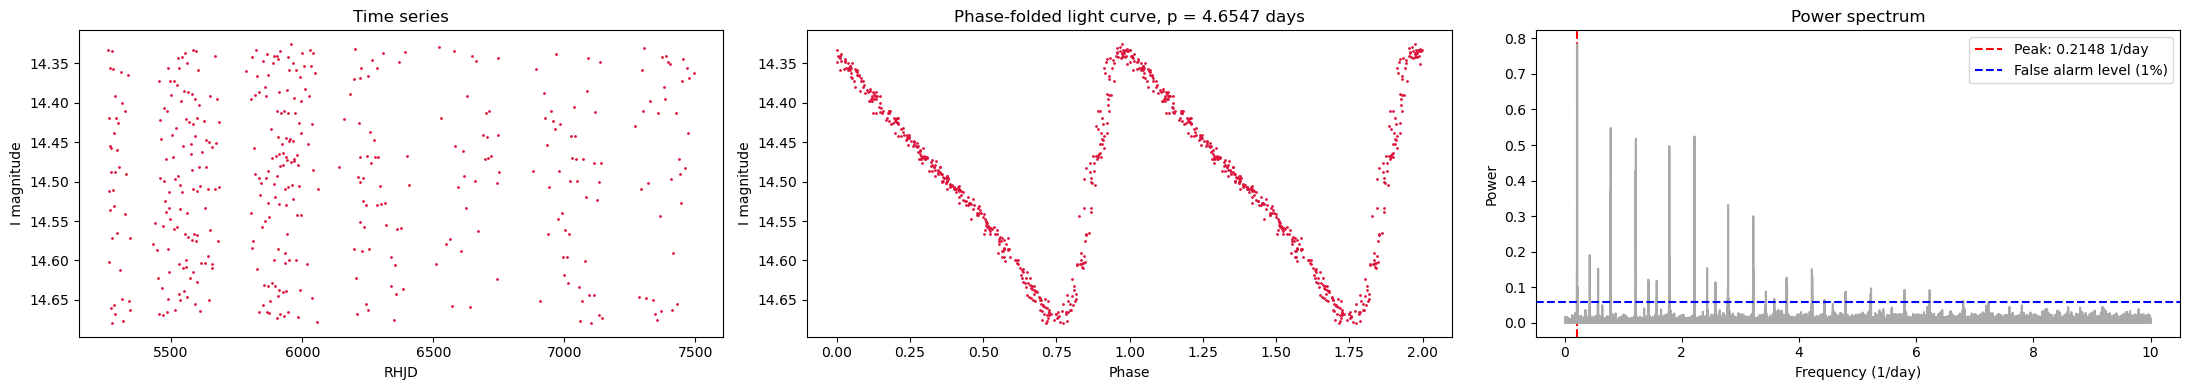

Procesando estrella 21/50: 14...


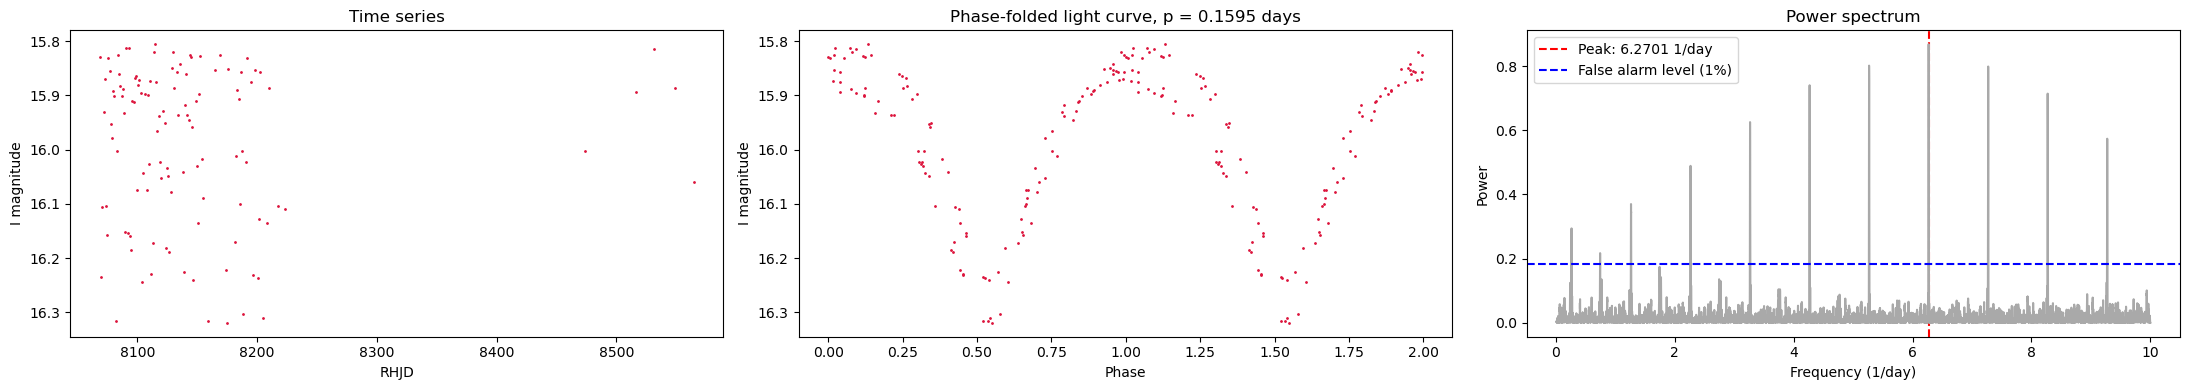

Procesando estrella 22/50: 15...


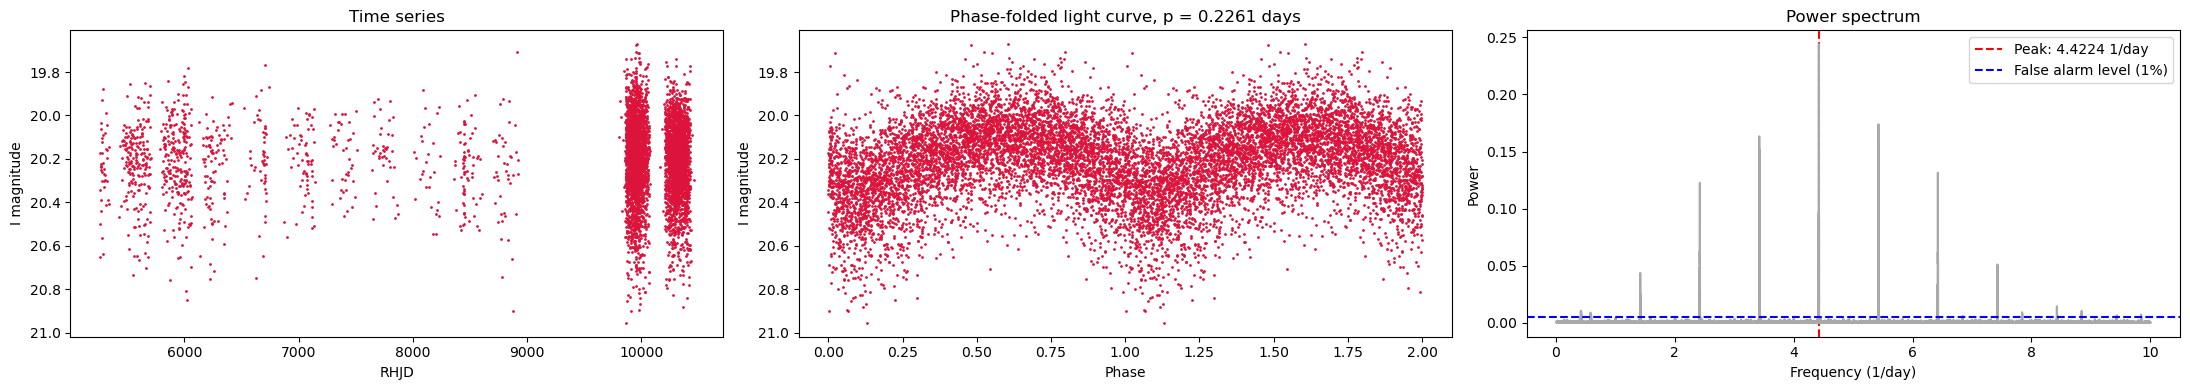

Procesando estrella 23/50: 16...


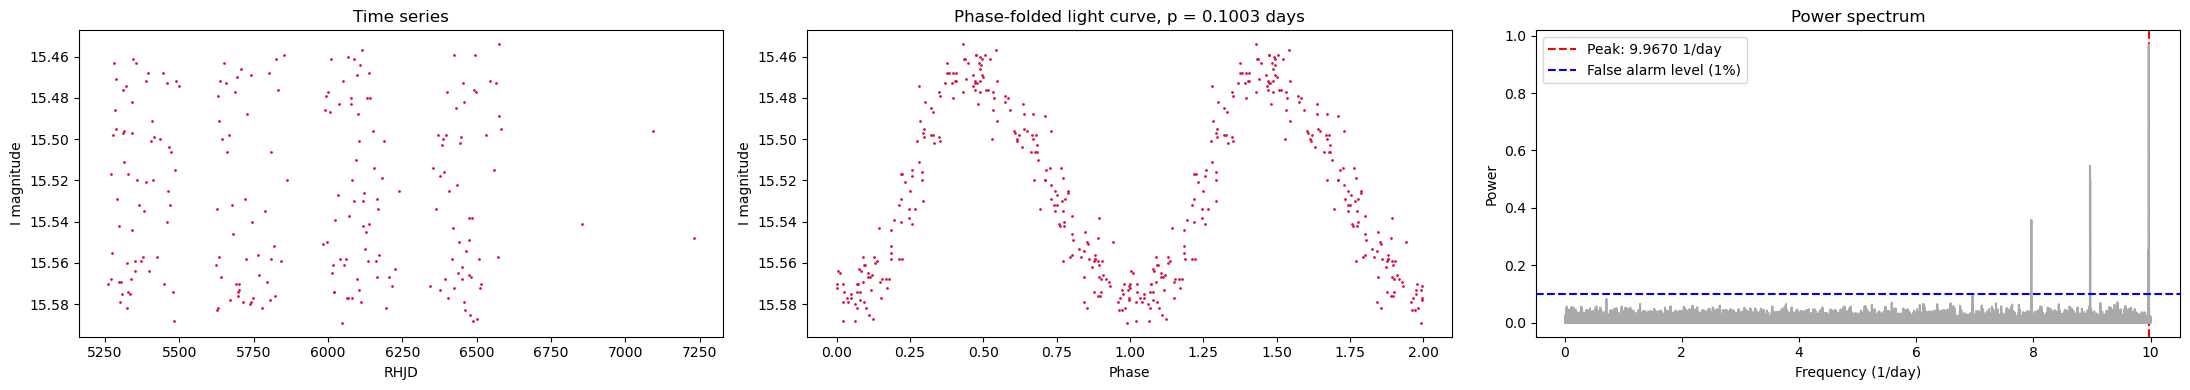

Procesando estrella 24/50: 17...


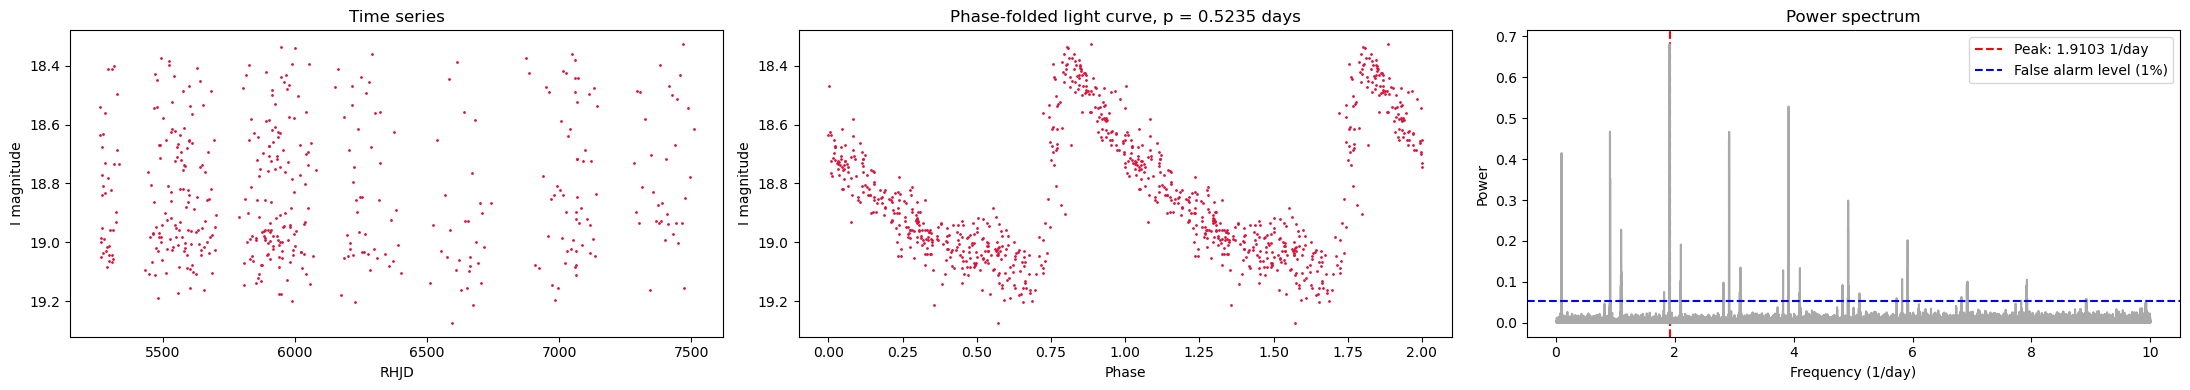

Procesando estrella 25/50: 18...


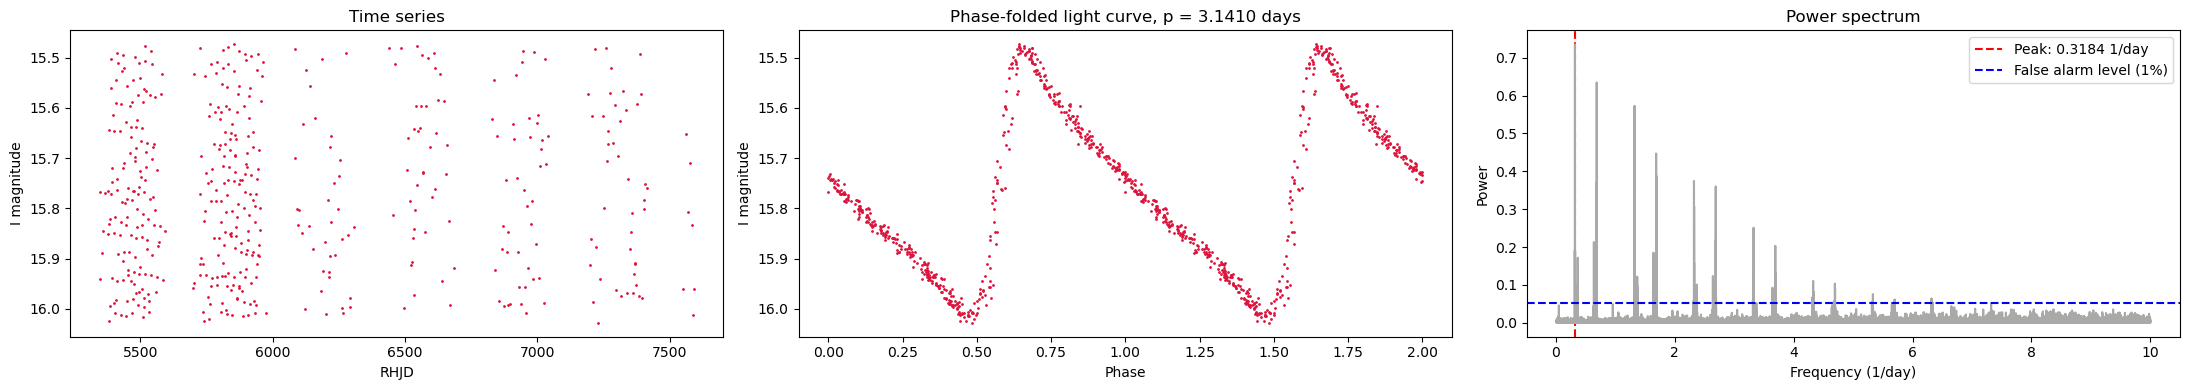

Procesando estrella 26/50: 19...


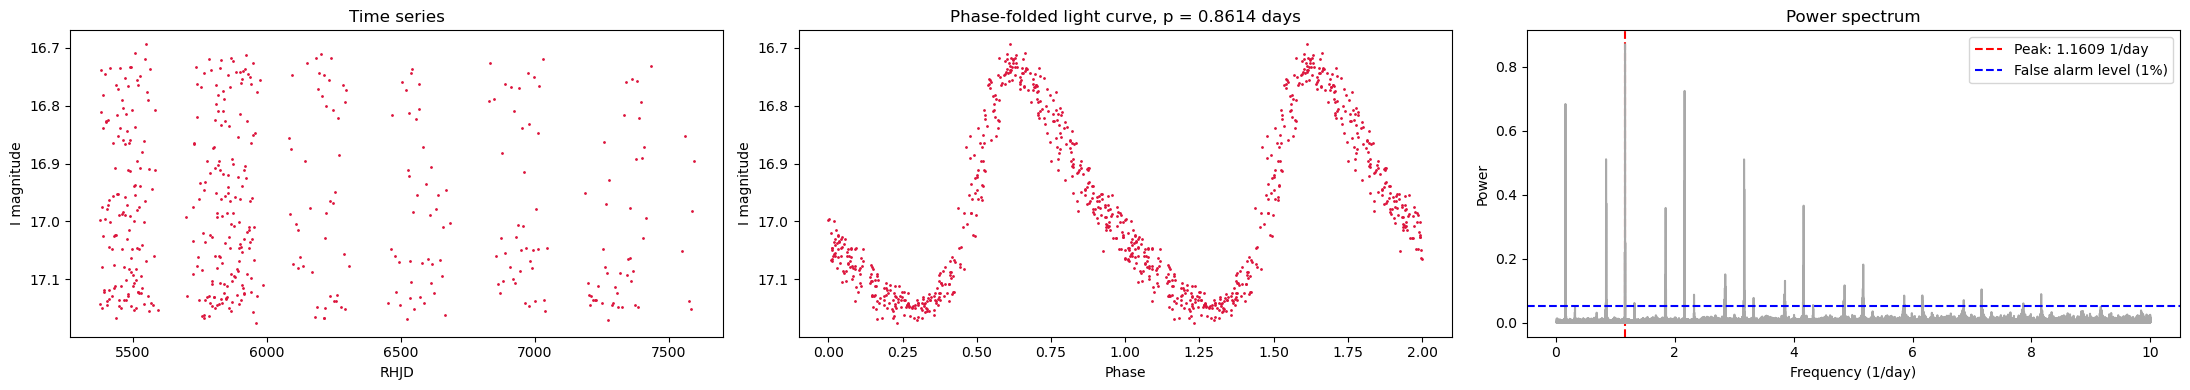

Procesando estrella 27/50: 1a...


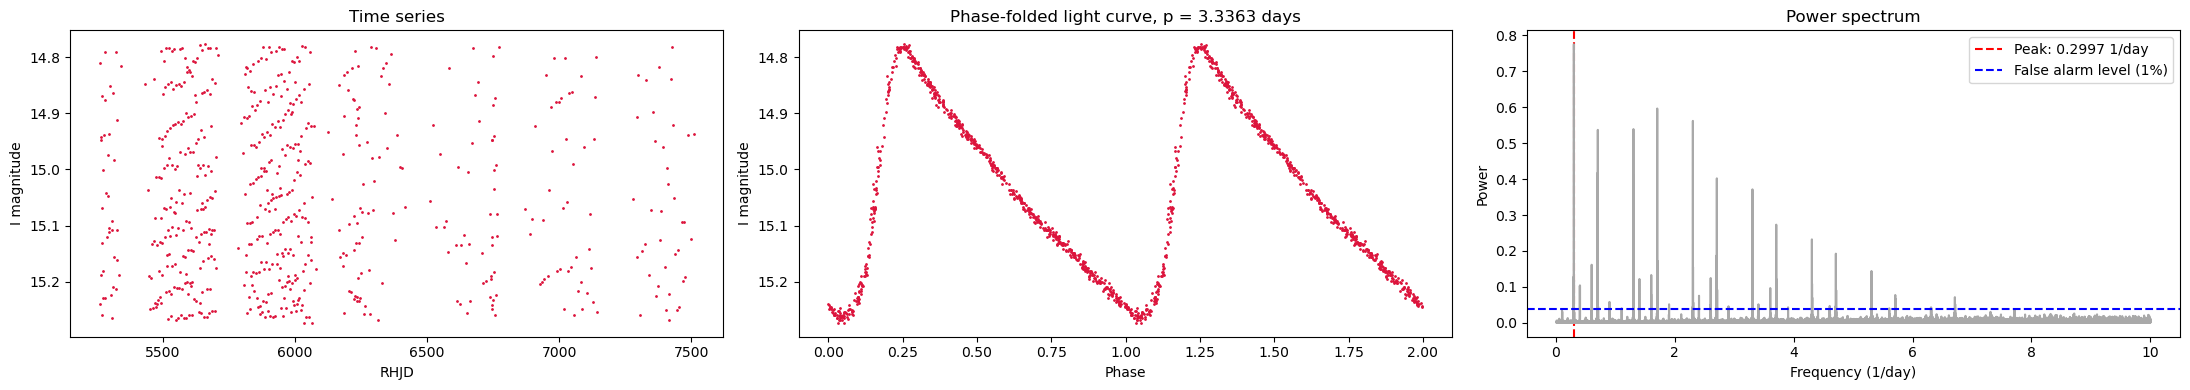

Procesando estrella 28/50: 1b...


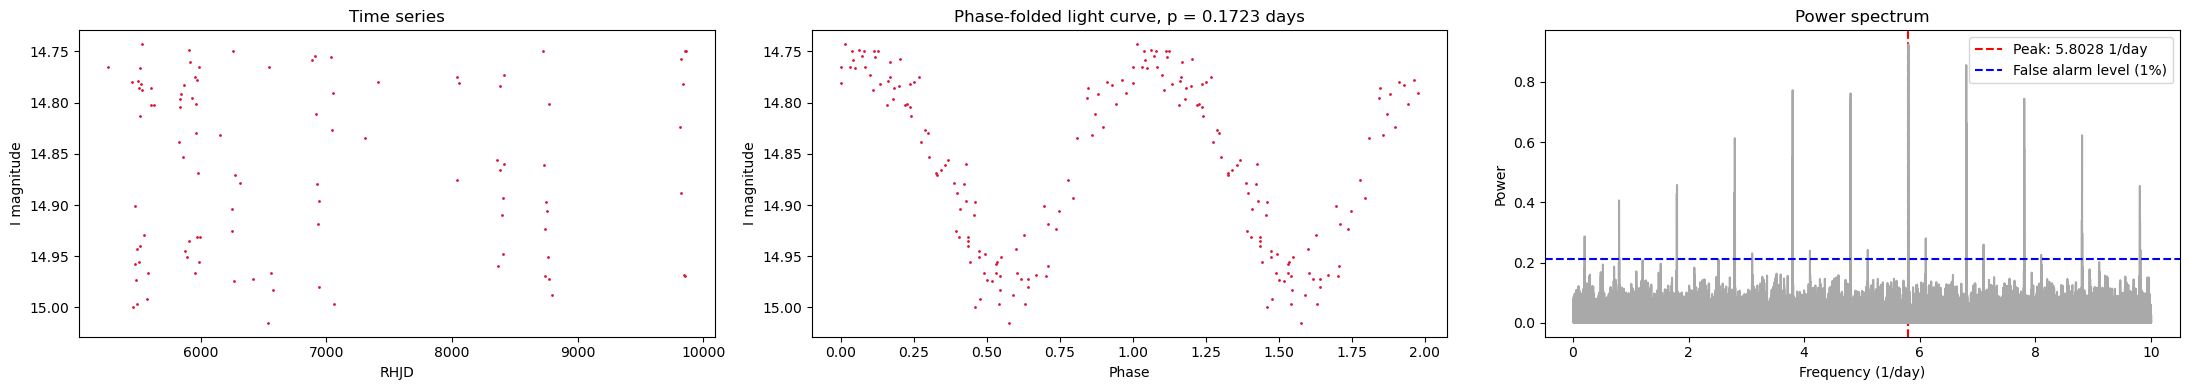

Procesando estrella 29/50: 1c...


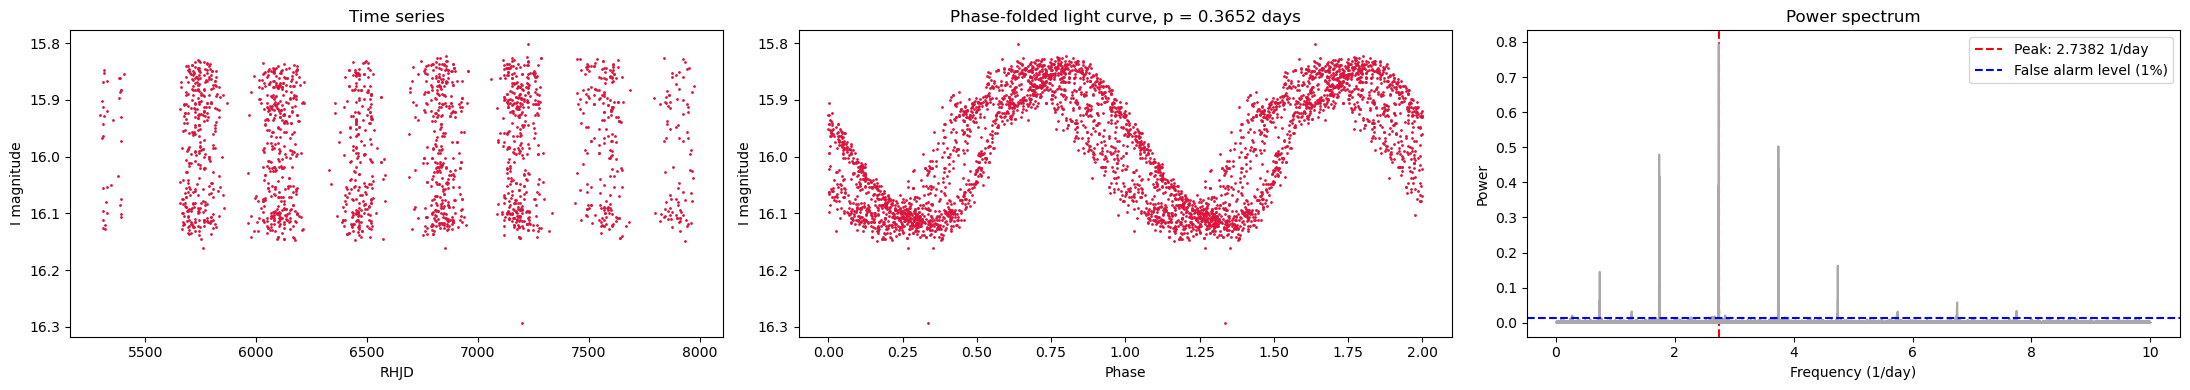

Procesando estrella 30/50: 1d...


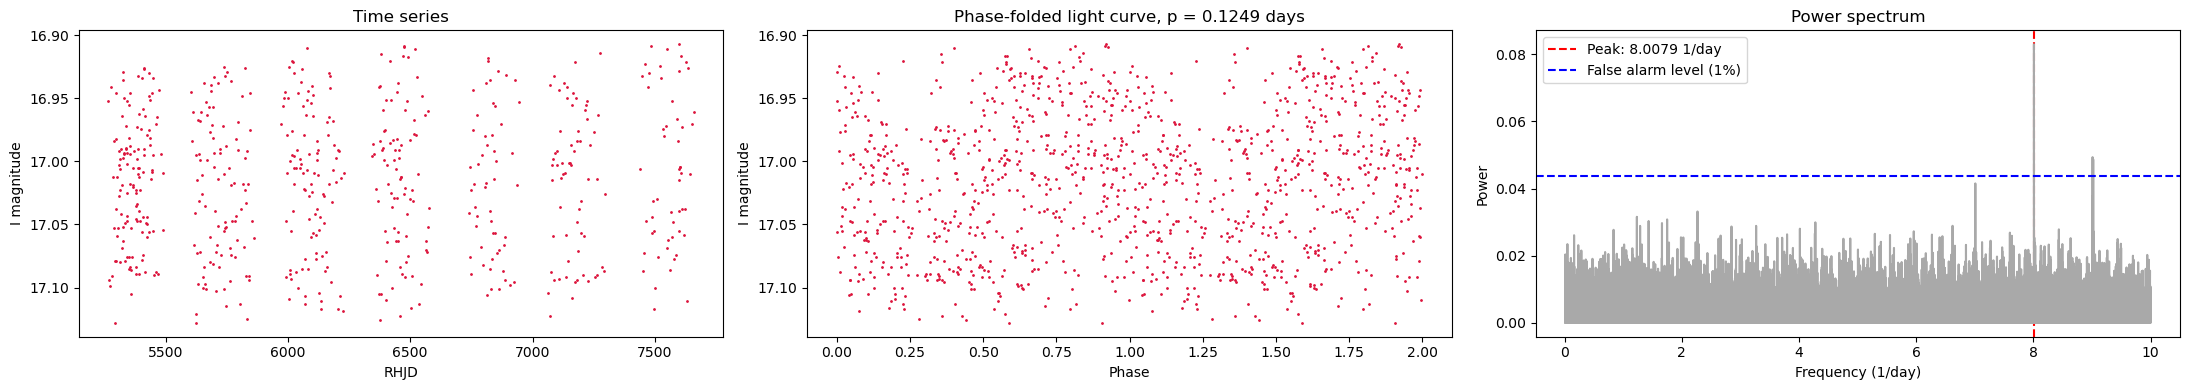

Procesando estrella 31/50: 1e...


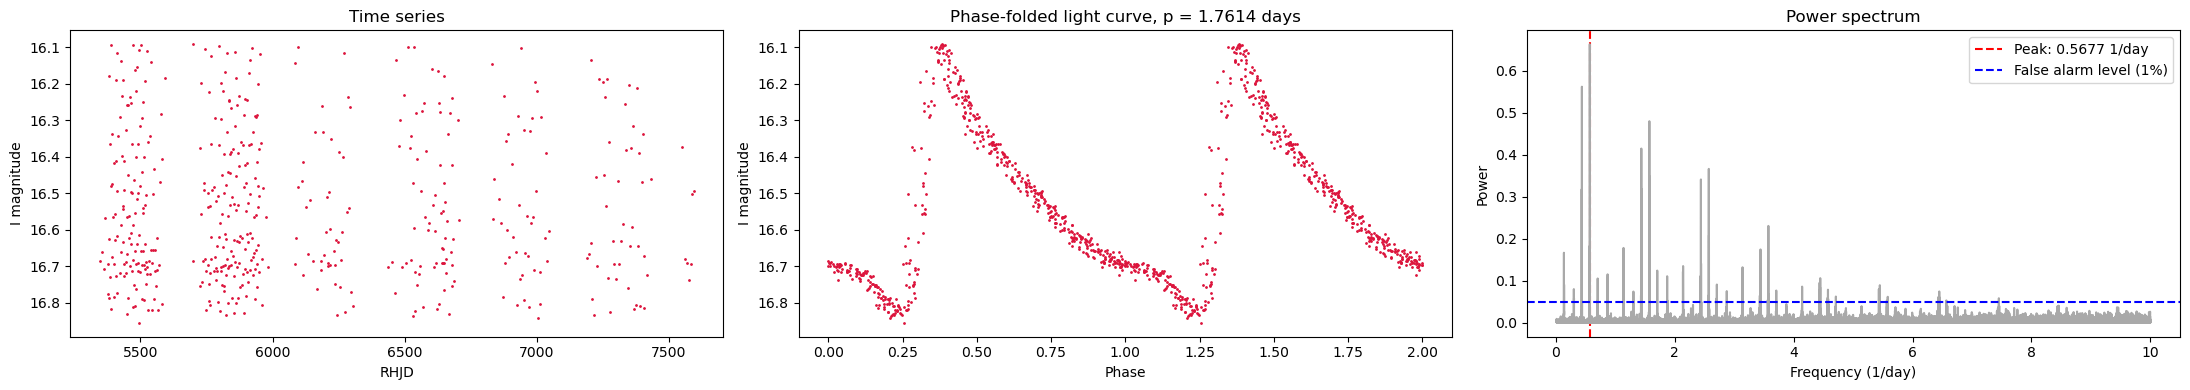

Procesando estrella 32/50: 1f...


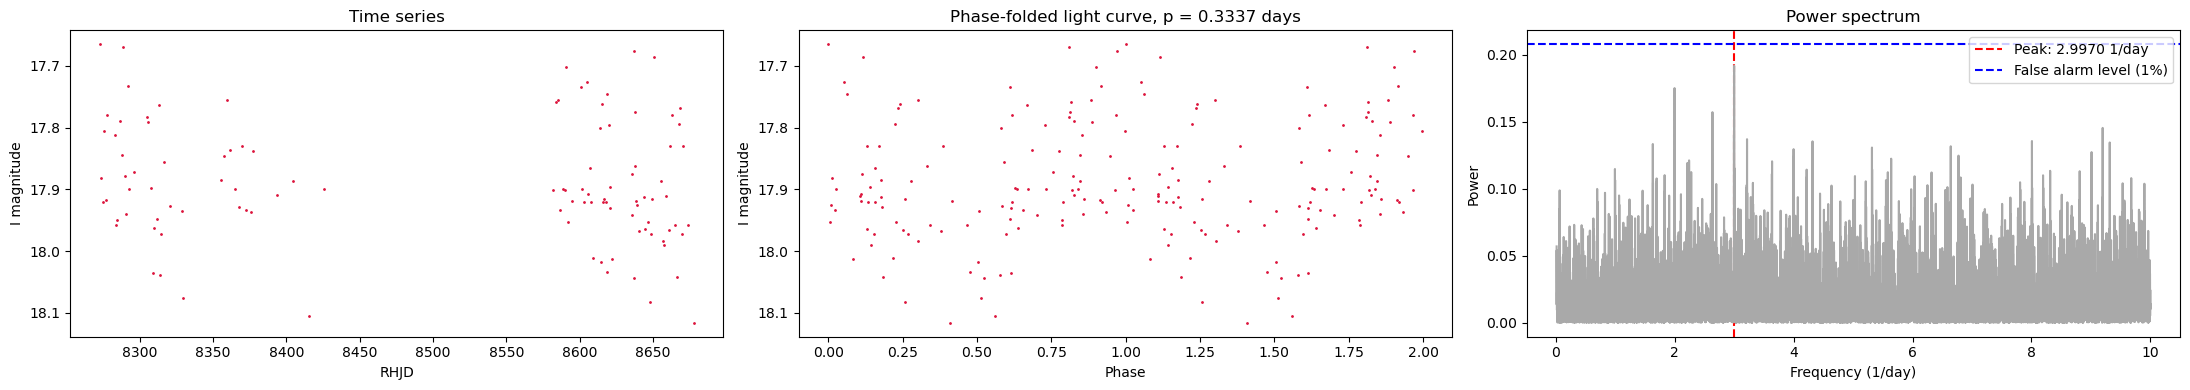

Procesando estrella 33/50: 20...


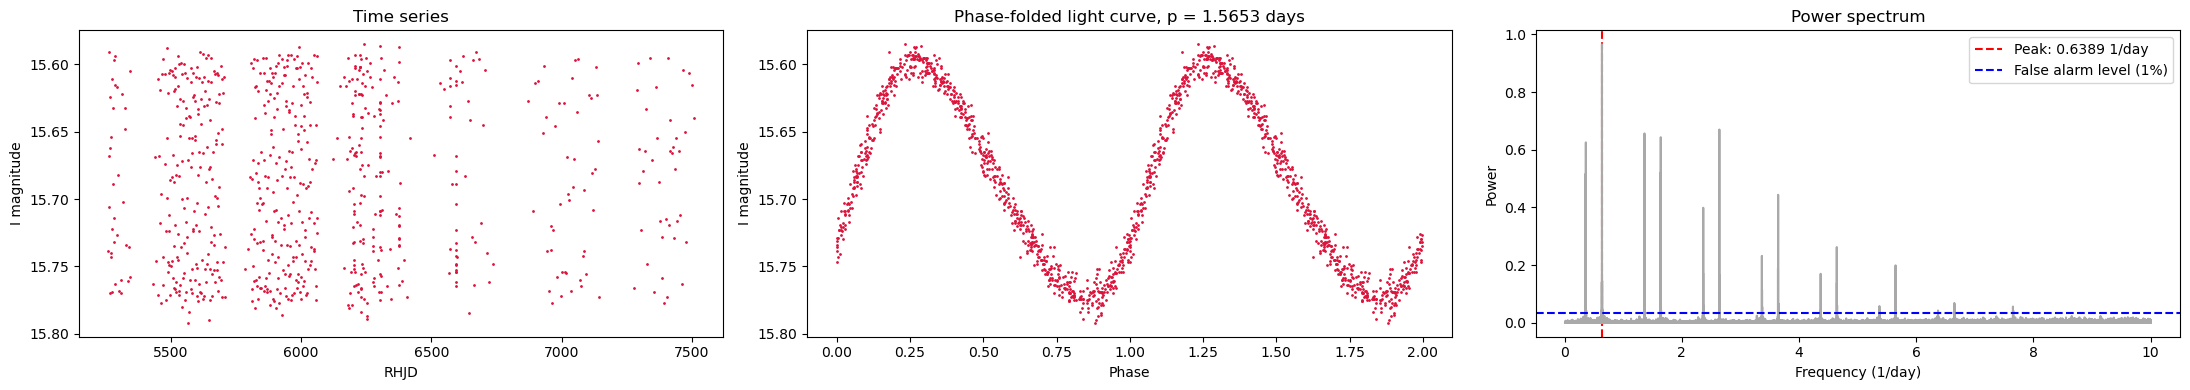

Procesando estrella 34/50: 21...


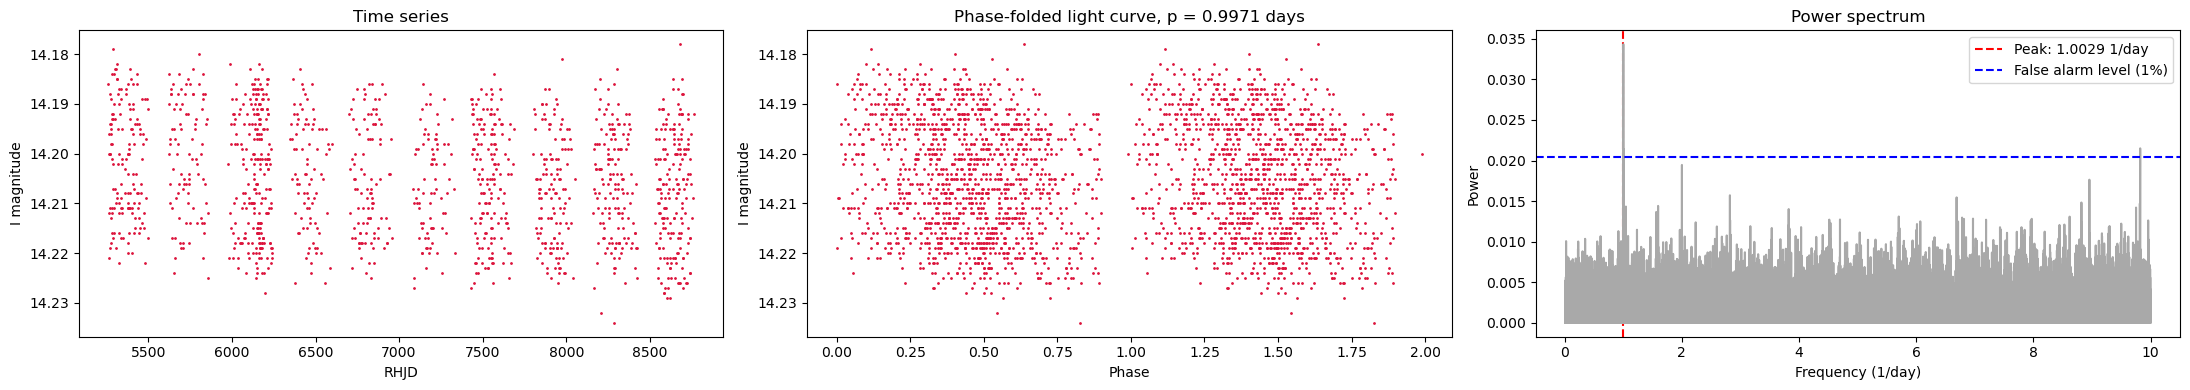

Procesando estrella 35/50: 22...


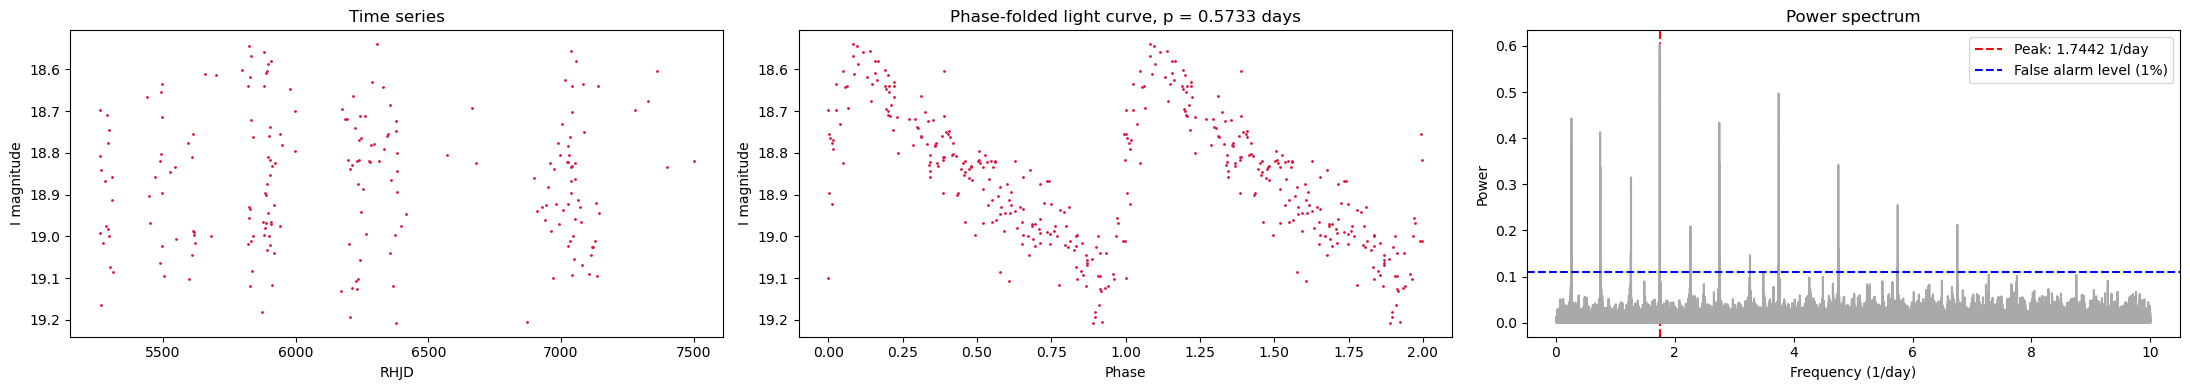

Procesando estrella 36/50: 23...


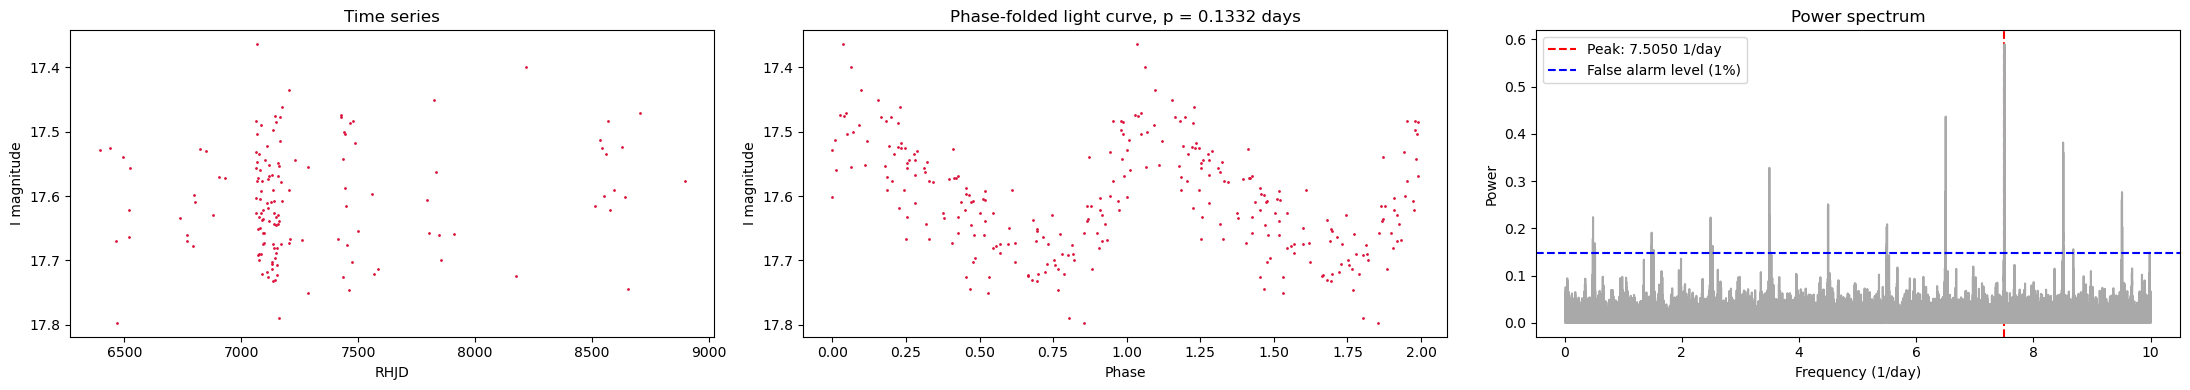

Procesando estrella 37/50: 24...


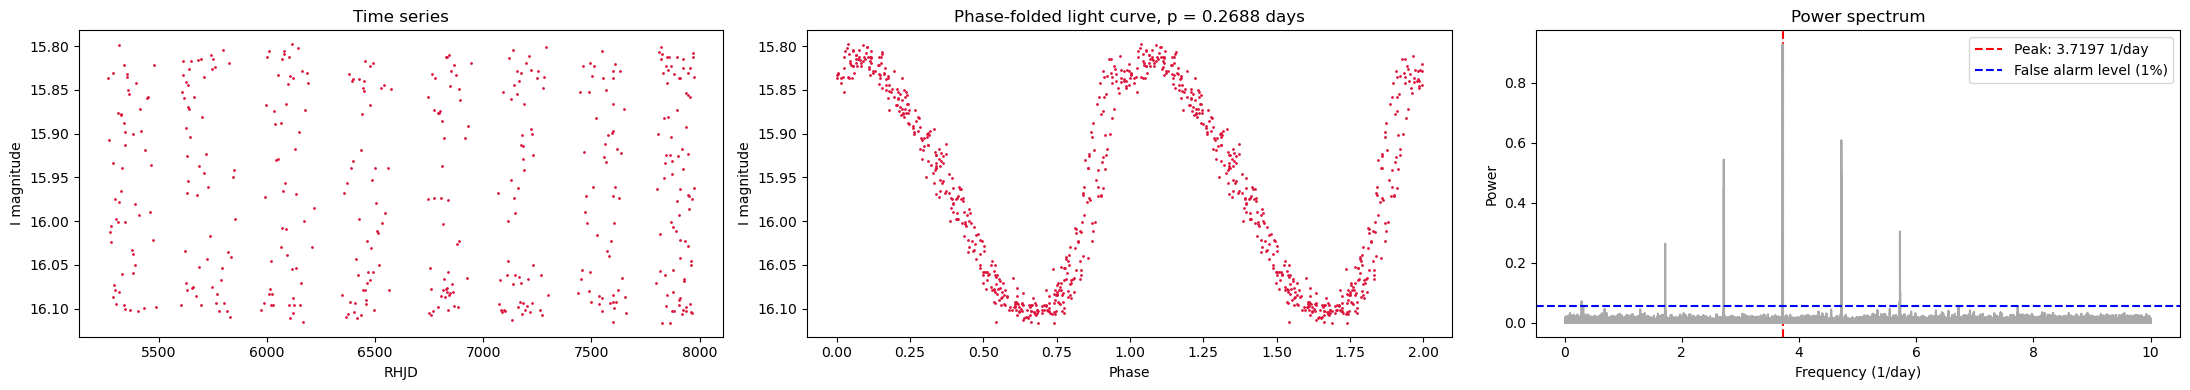

Procesando estrella 38/50: 25...


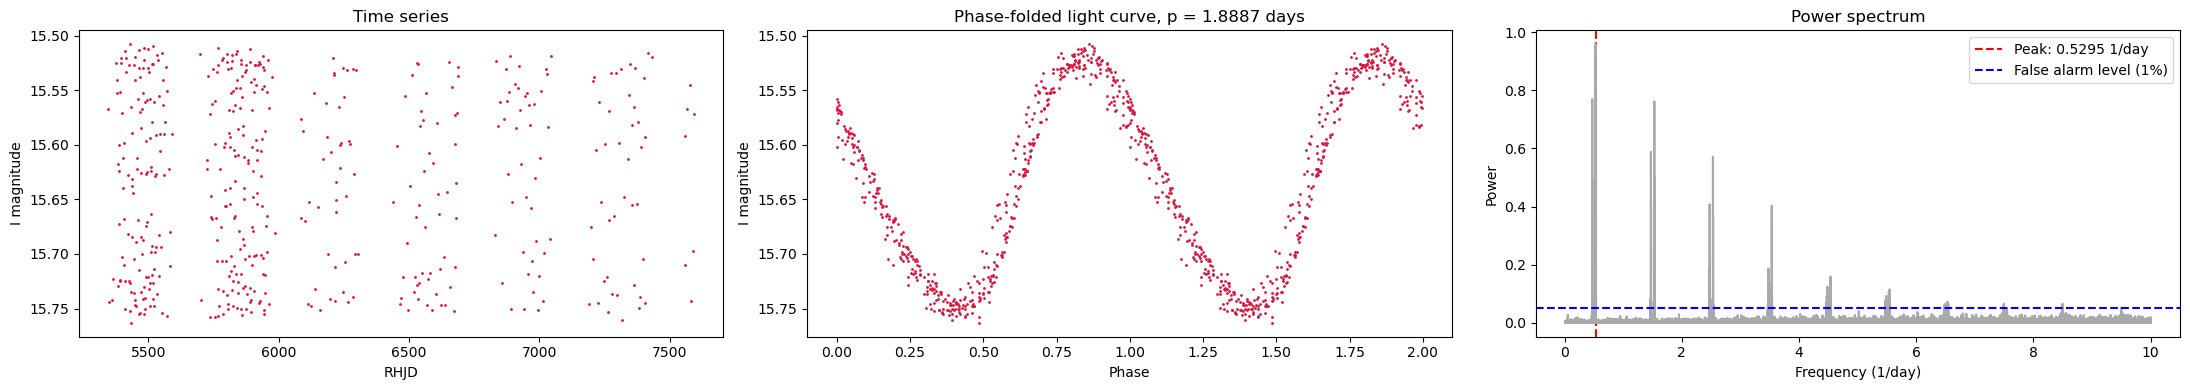

Procesando estrella 39/50: 26...


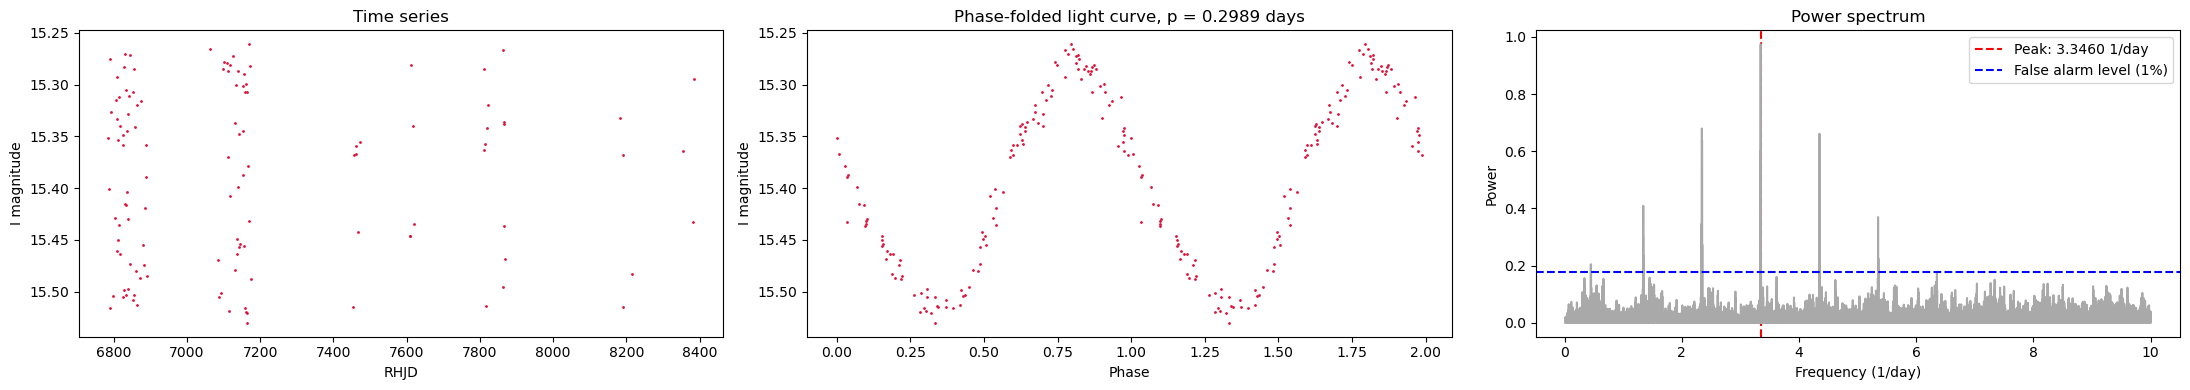

Procesando estrella 40/50: 27...


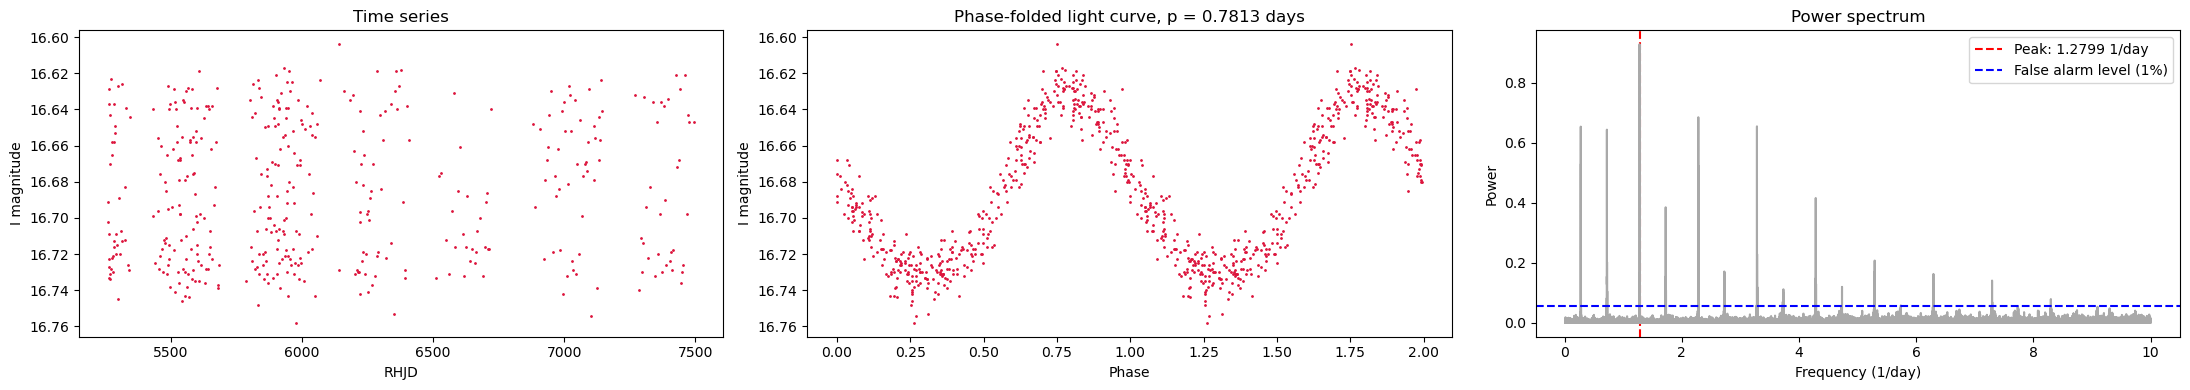

Procesando estrella 41/50: 28...


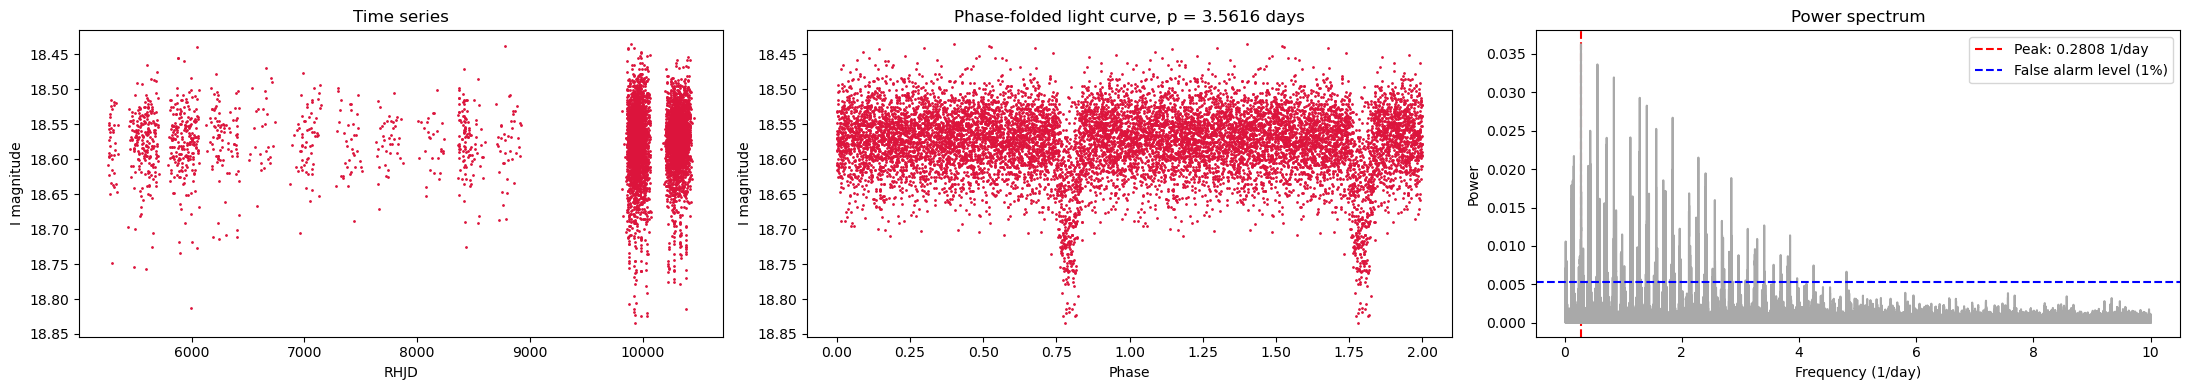

Procesando estrella 42/50: 29...


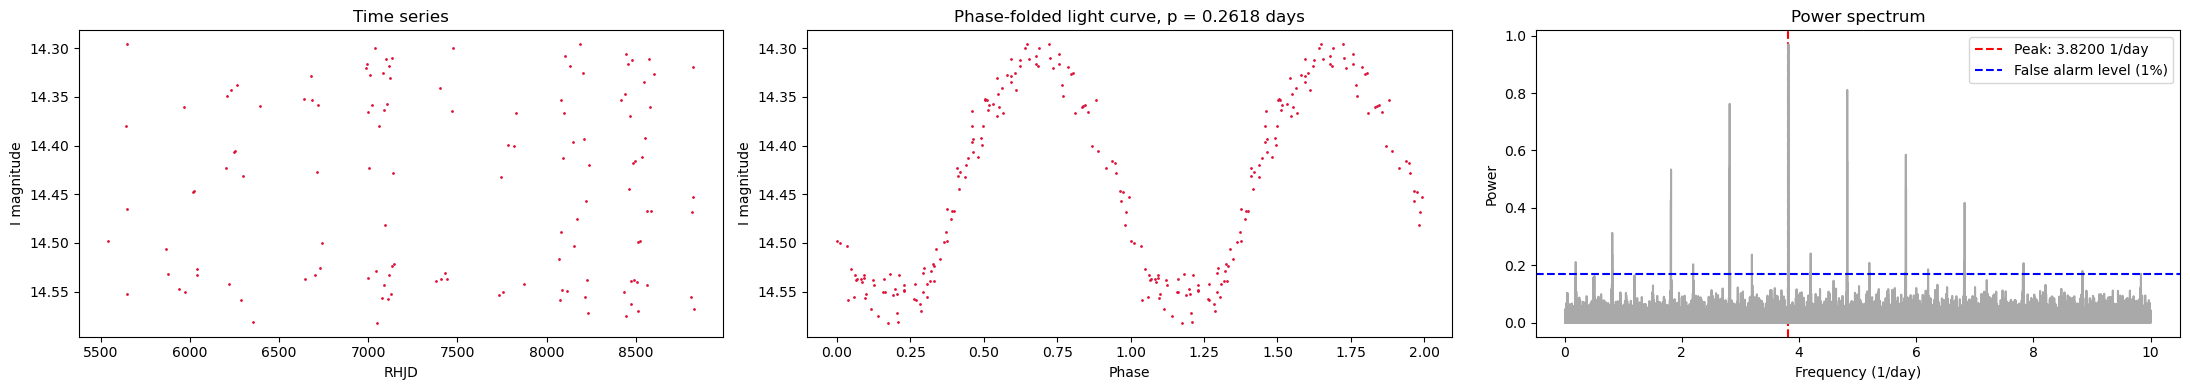

Procesando estrella 43/50: 2a...


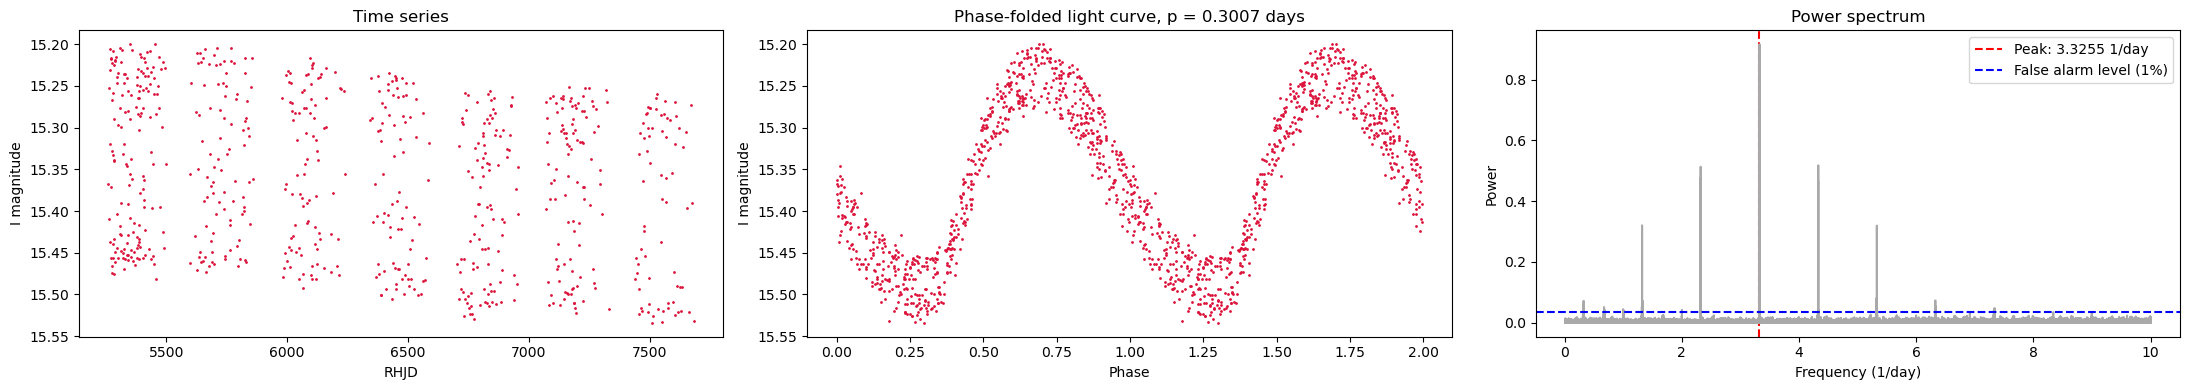

Procesando estrella 44/50: 2b...


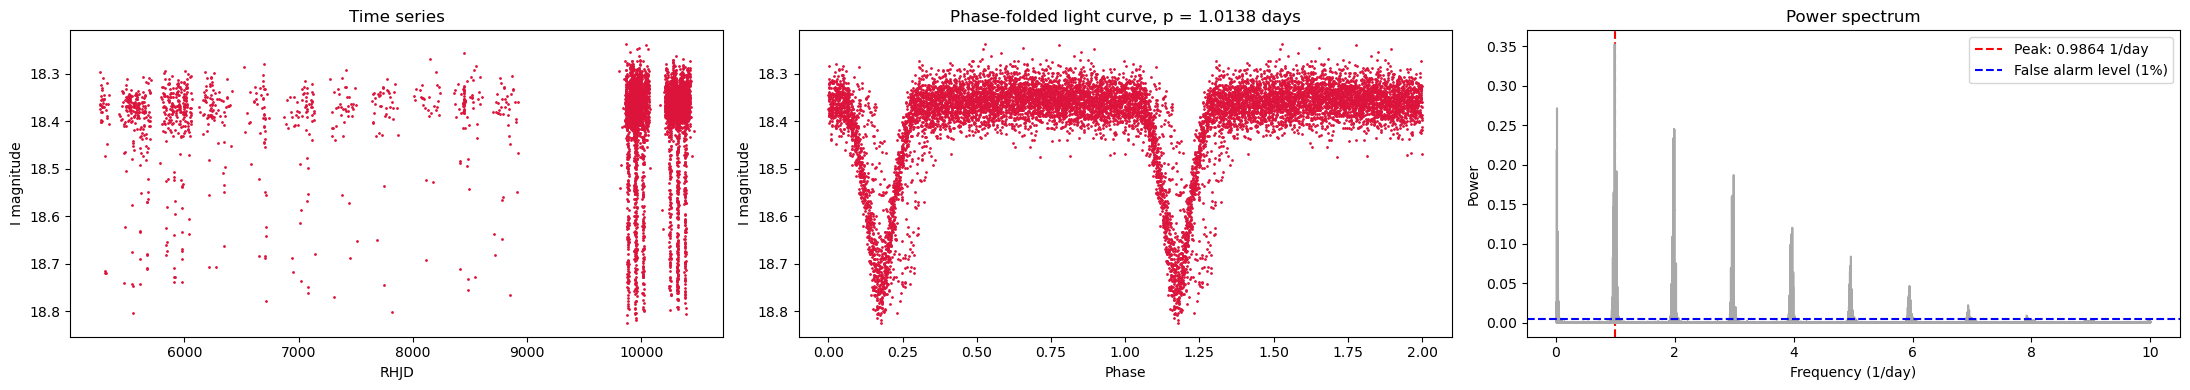

Procesando estrella 45/50: 2c...


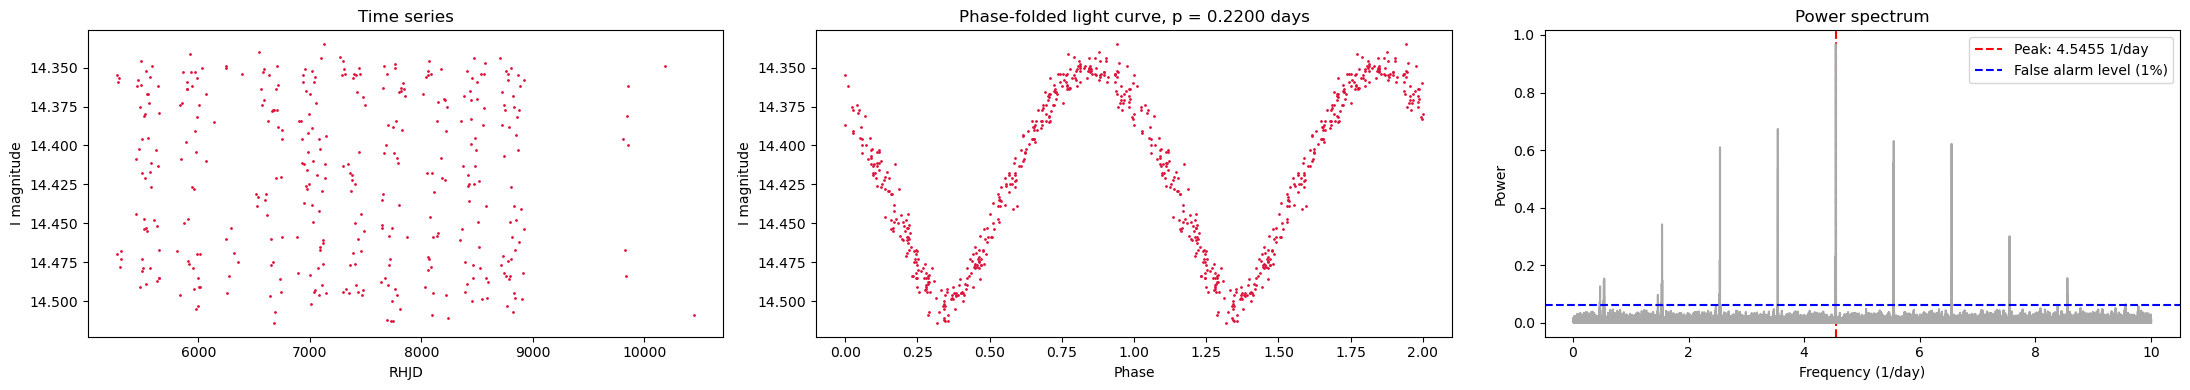

Procesando estrella 46/50: 2d...


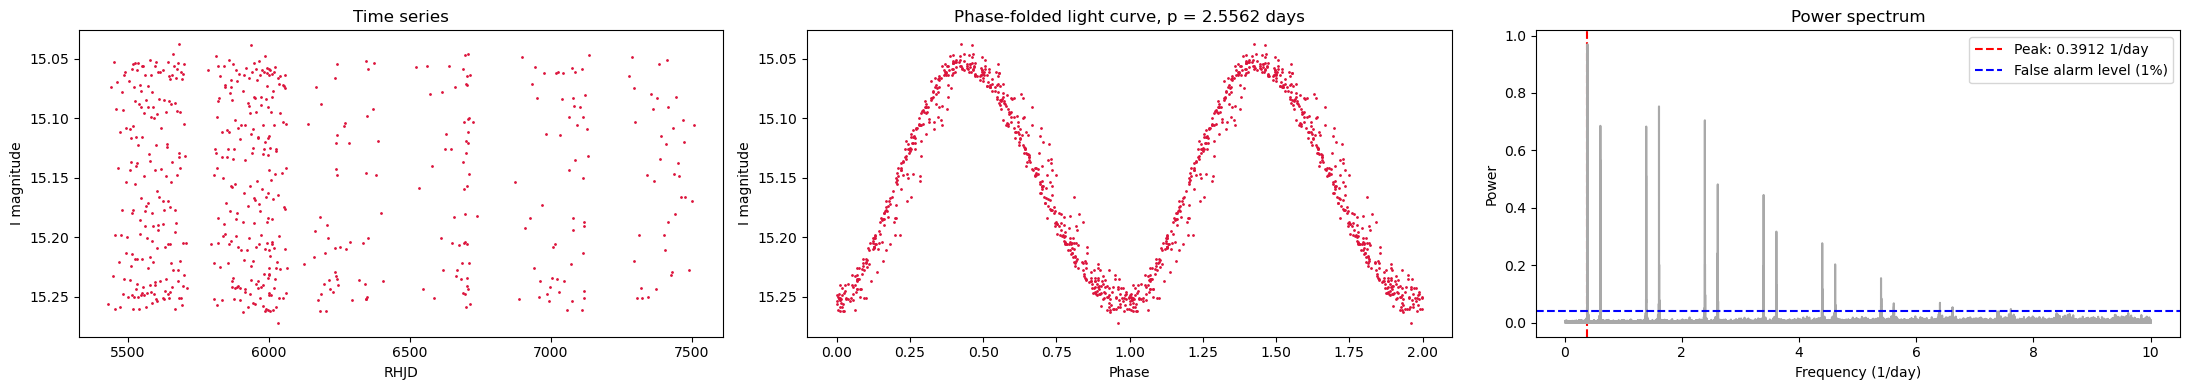

Procesando estrella 47/50: 2e...


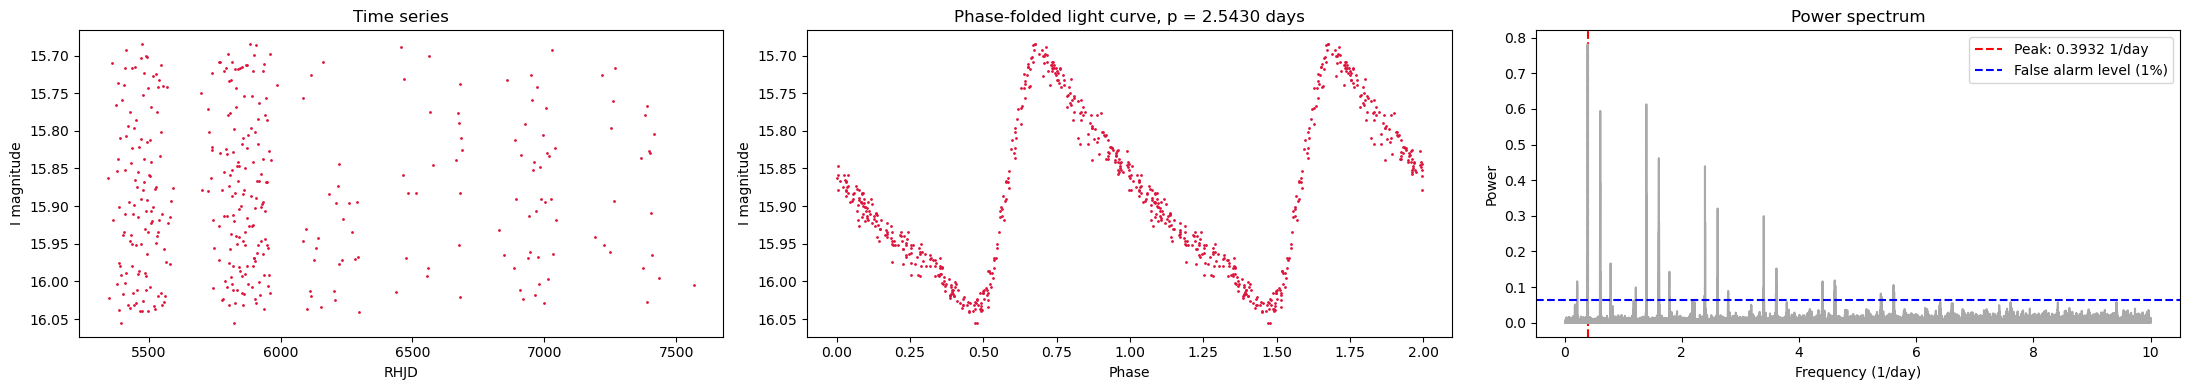

Procesando estrella 48/50: 2f...


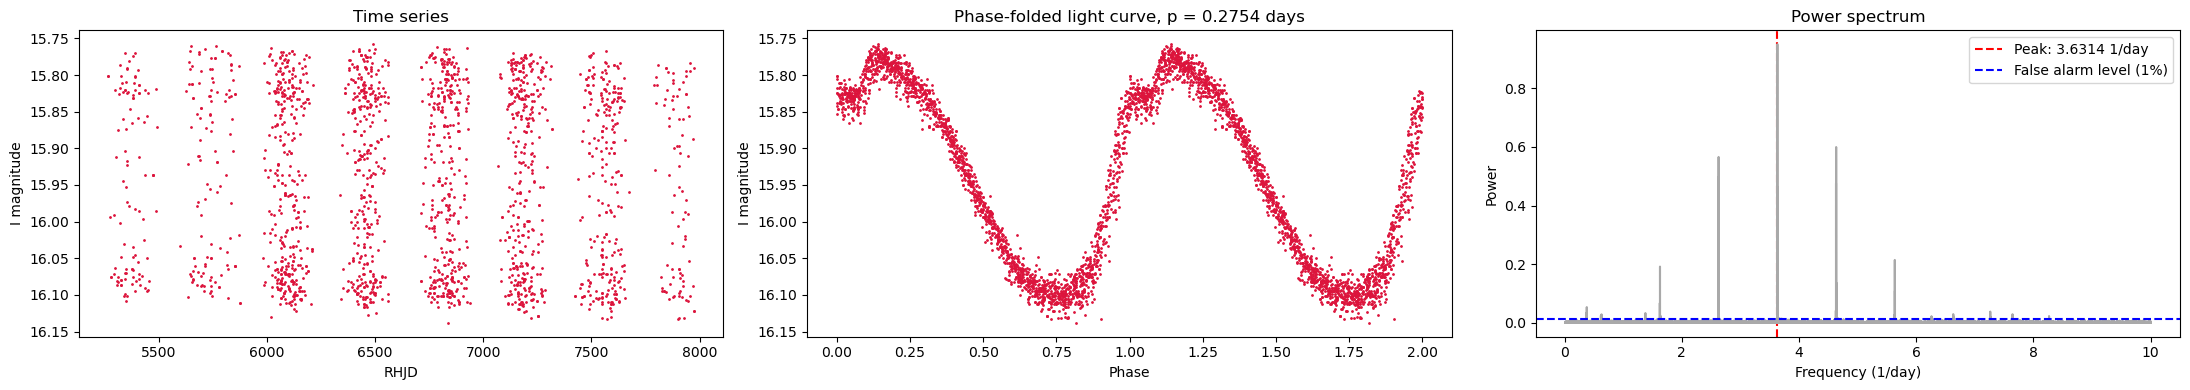

Procesando estrella 49/50: 30...


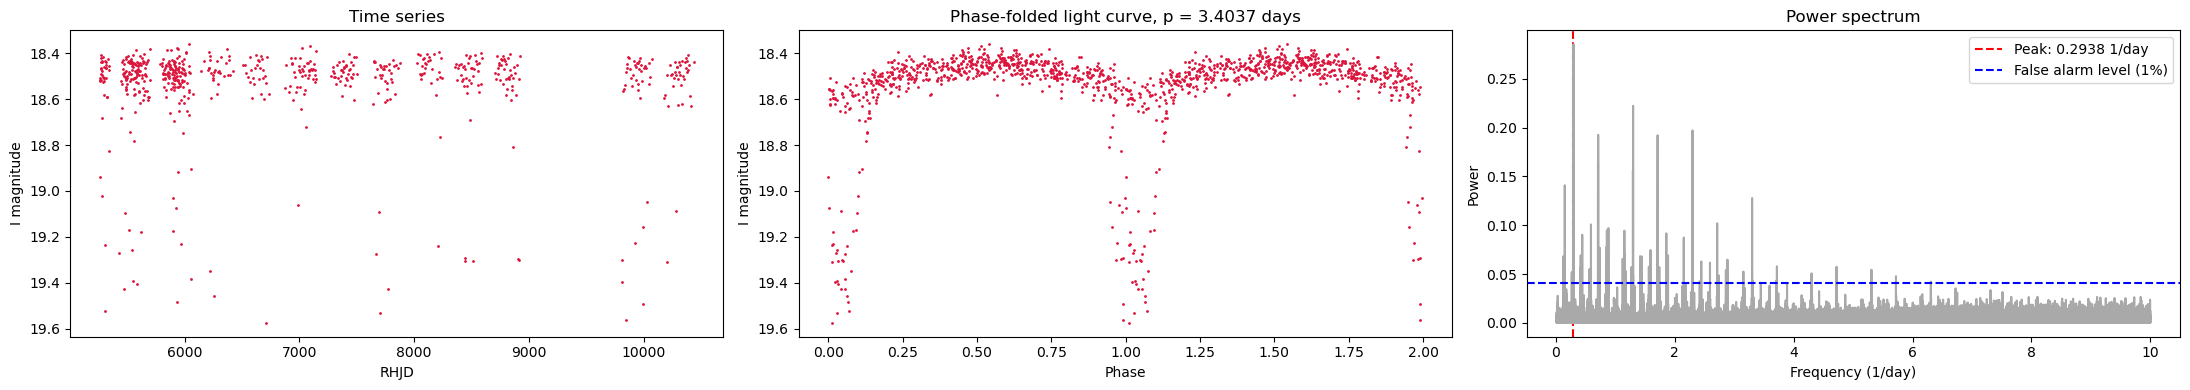

Procesando estrella 50/50: 31...


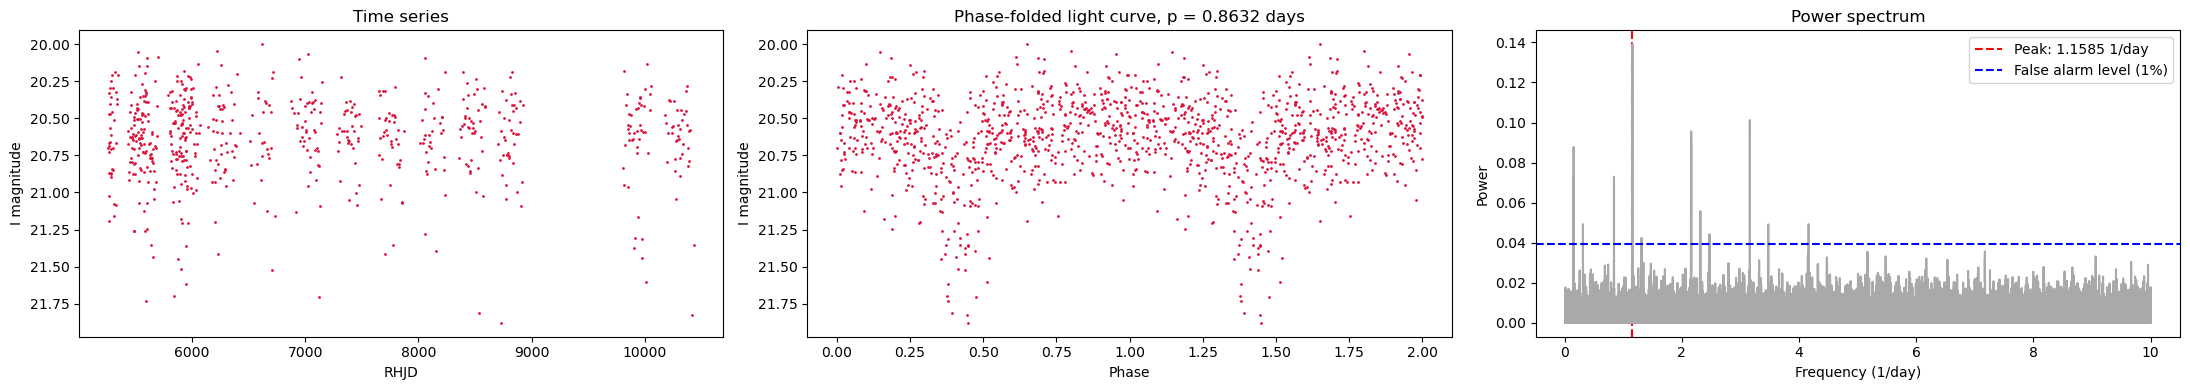

In [ ]:
#LOMB-SCARGLE
def phase_folding(periodo, mjd):
    phase = ((mjd - mjd[0]) % periodo) / periodo
    return phase

db = "singlemode_variable_stars_sample.h5"

# 1. Abrimos el archivo HDF5 UNA SOLA VEZ (mucho más rápido que abrirlo en cada iteración)
with h5py.File(db, "r") as file:
    star_codes = list(file["/"].keys())
    
    # Seleccionamos solo las primeras 50 estrellas
    estrellas_a_procesar = star_codes[:50]
    
    for i, name in enumerate(estrellas_a_procesar):
        print(f"Procesando estrella {i+1}/50: {name}...")
        
        # 2. Extracción de datos
        star_data = pd.DataFrame(file[name][:])
        mjd = star_data.RHJD
        mag = star_data.mag
        
        # 3. Cálculo de Lomb-Scargle
        # Instanciamos una sola vez para reutilizarlo en autopower y false_alarm_level
        ls = LombScargle(mjd, mag)
        frequency, power = ls.autopower(minimum_frequency=1/101, maximum_frequency=10)
        
        frequency_max = frequency[np.argmax(power)]
        period_max = 1 / frequency_max
        phase = phase_folding(period_max, mjd)
        
        # 4. Generación de Gráficas
        plt.figure(figsize=(22, 4))
        
        # Panel 1: Serie de tiempo
        plt.subplot(1, 3, 1)
        plt.scatter(mjd, mag, c='crimson', s=1)
        plt.gca().invert_yaxis()
        plt.title(f"Time series")
        plt.xlabel("RHJD")
        plt.ylabel("I magnitude")
        
        # Panel 2: Curva de luz plegada en fase (con el ciclo duplicado)
        plt.subplot(1, 3, 2)
        plt.scatter(phase, mag, c='crimson', s=1)
        plt.scatter(phase + 1, mag, c='crimson', s=1)
        plt.gca().invert_yaxis()
        plt.title(f"Phase-folded light curve, p = {period_max:.4f} days")
        plt.xlabel("Phase")
        plt.ylabel("I magnitude")
        
        # Panel 3: Espectro de potencia
        plt.subplot(1, 3, 3)
        plt.plot(frequency, power, color='darkgray')
        plt.axvline(frequency_max, color='red', linestyle='--', label=f'Peak: {frequency_max:.4f} 1/day', zorder=-10)
        
        # Nivel de falsa alarma (FAL)
        # Nota de rendimiento: Si el cálculo se vuelve muy lento, añade method='baluev' dentro de false_alarm_level
        fal_1_percent = ls.false_alarm_level(0.01) 
        plt.axhline(fal_1_percent, color='blue', linestyle='--', label='False alarm level (1%)')
        
        plt.legend()
        plt.xlabel('Frequency (1/day)')
        plt.ylabel('Power')
        plt.title('Power spectrum')
        
        plt.tight_layout()
    
        plt.show() 
        plt.close()


Puntos originales: 50000. Puntos tras limpiar alias: 49178
Procesando estrella 1/20: 00...


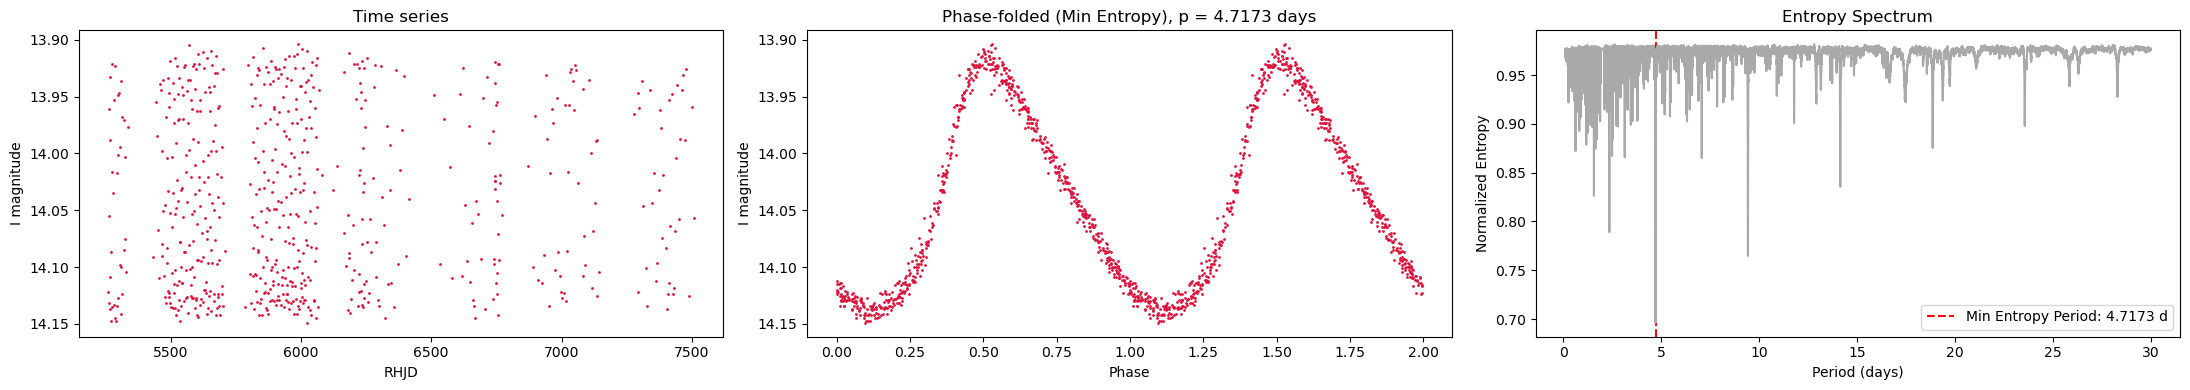

Procesando estrella 2/20: 01...


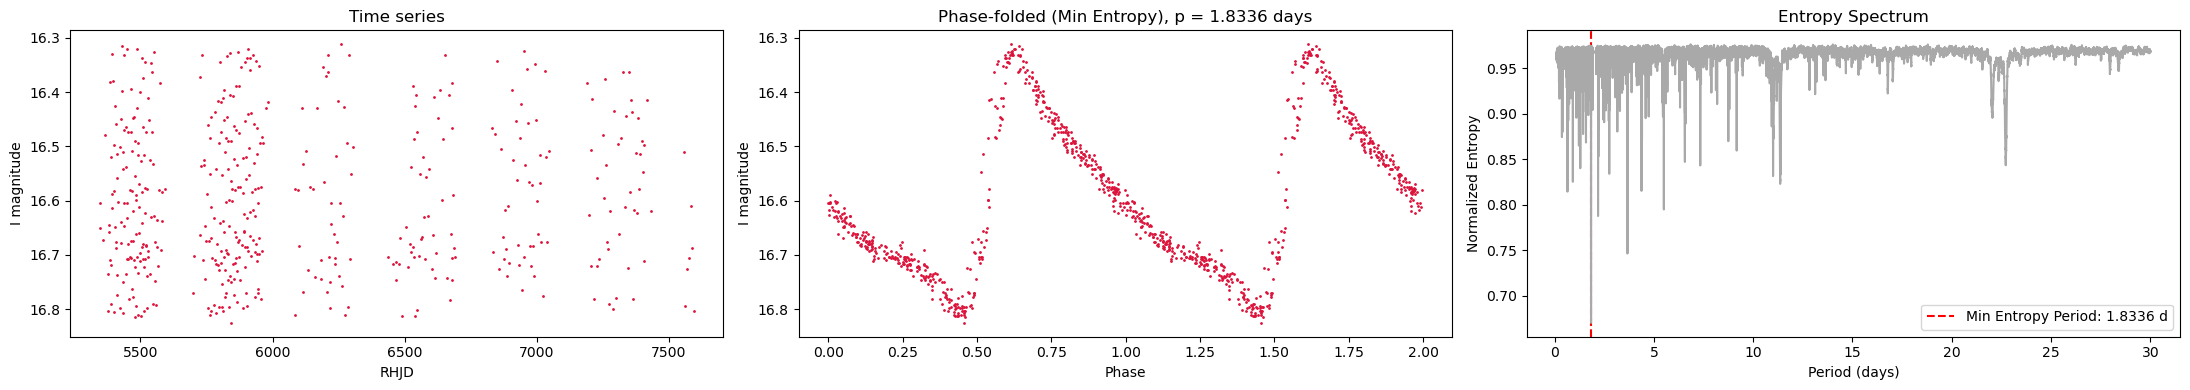

Procesando estrella 3/20: 02...


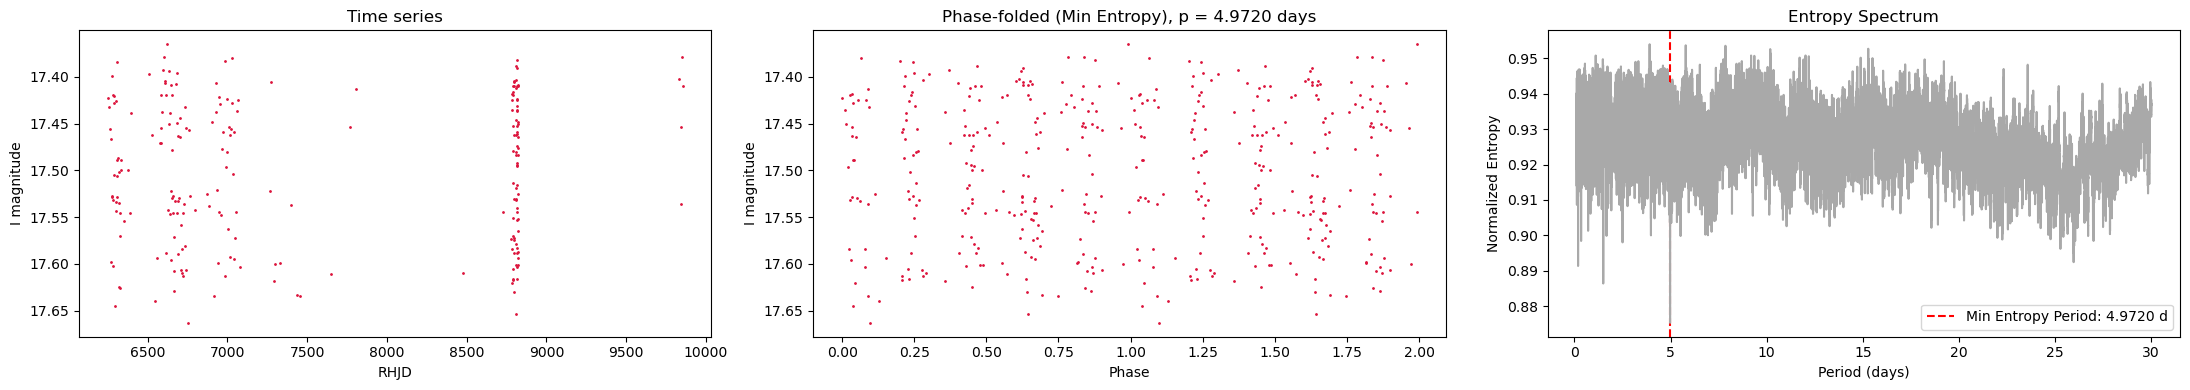

Procesando estrella 4/20: 03...


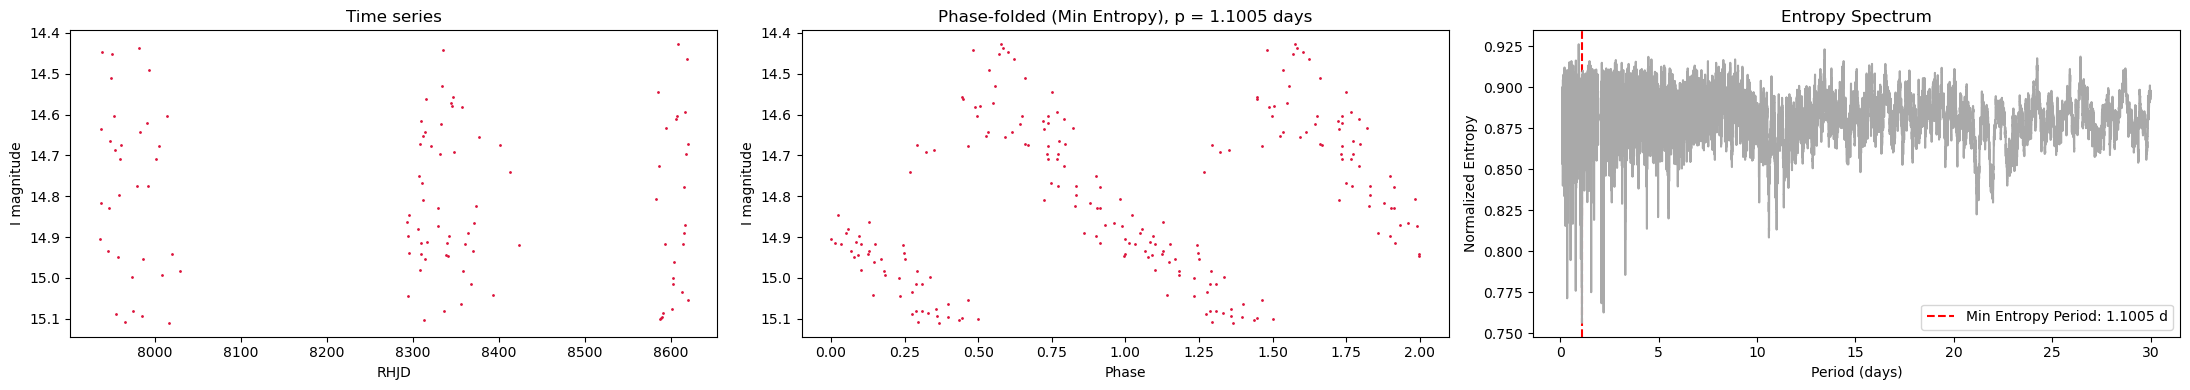

Procesando estrella 5/20: 04...


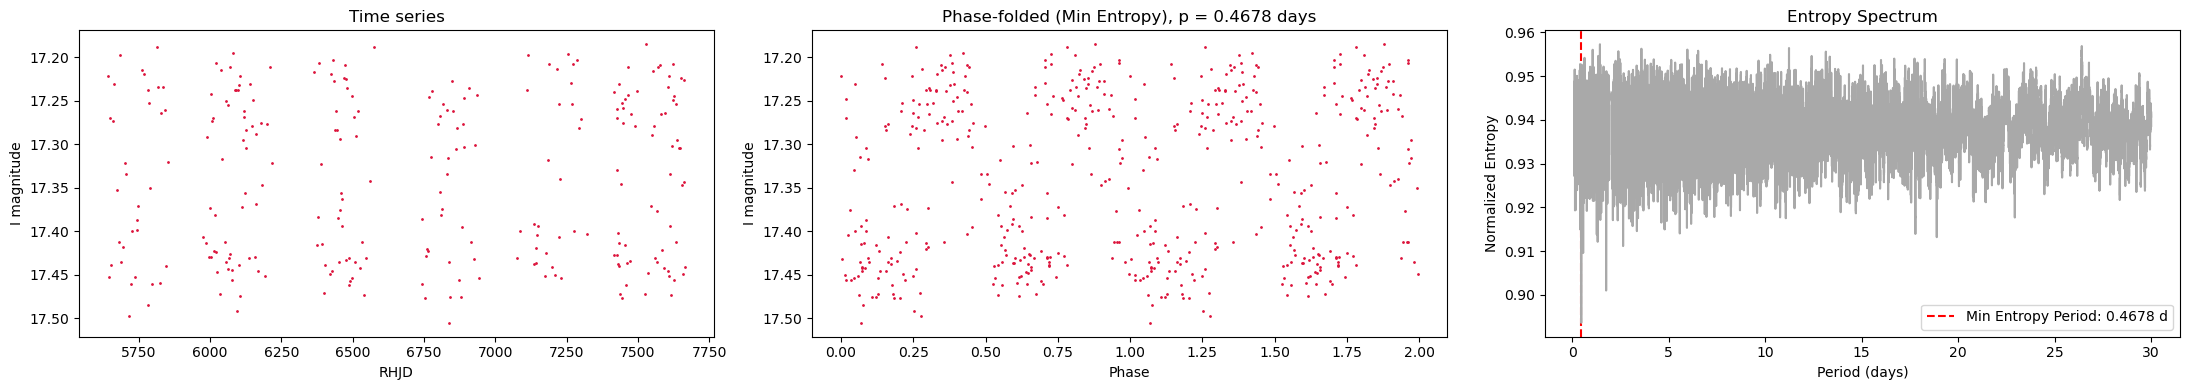

Procesando estrella 6/20: 05...


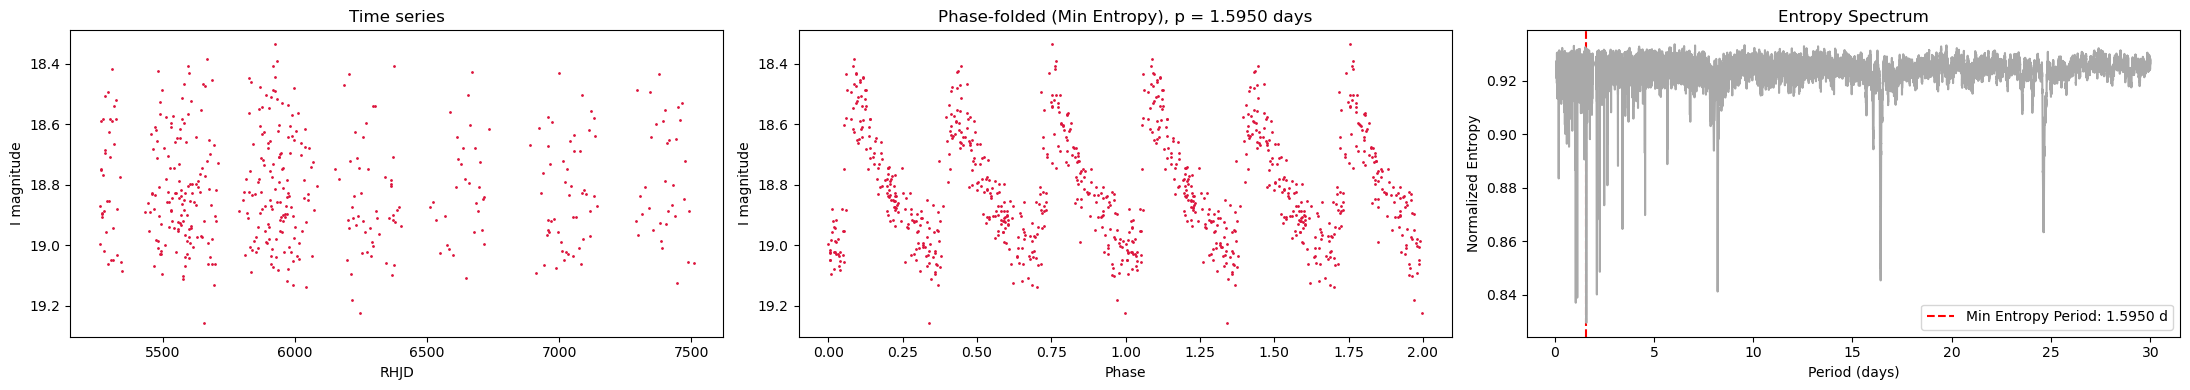

Procesando estrella 7/20: 06...


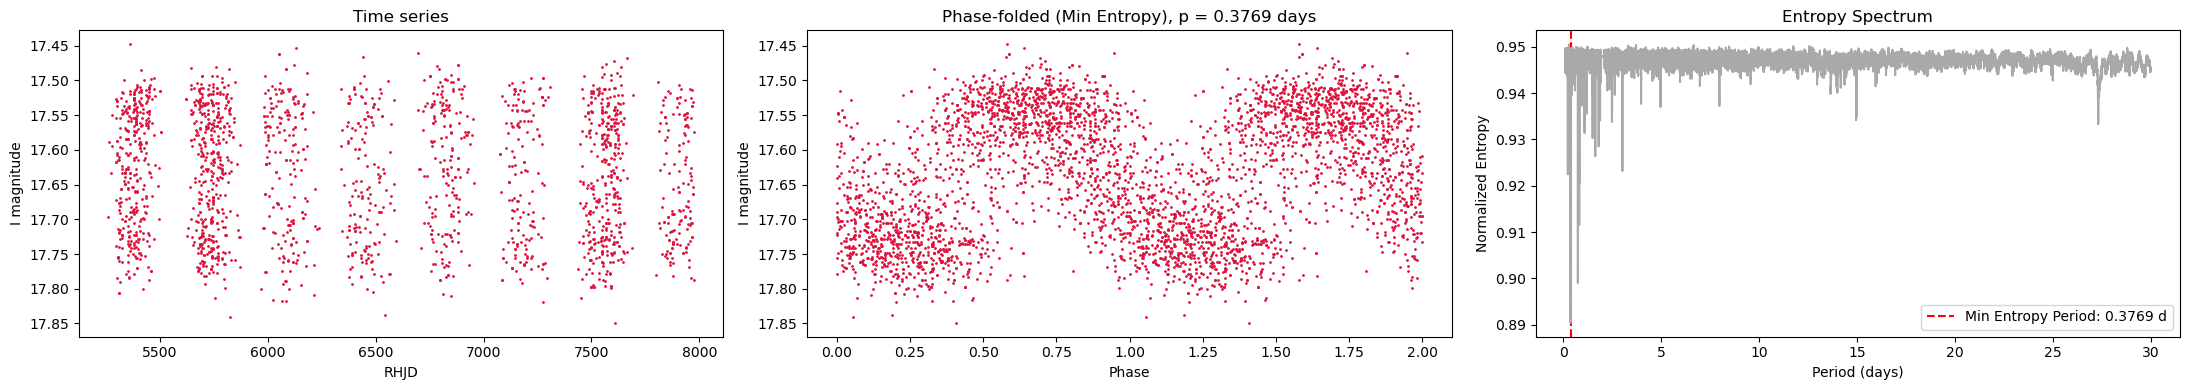

Procesando estrella 8/20: 07...


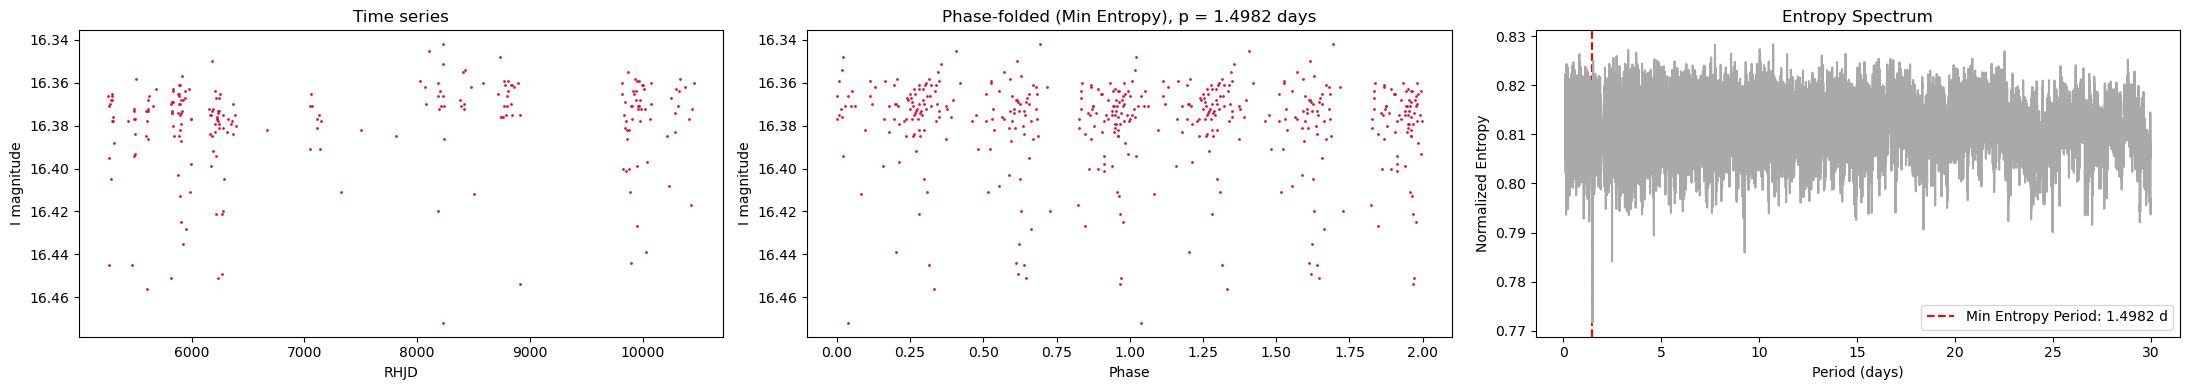

Procesando estrella 9/20: 08...


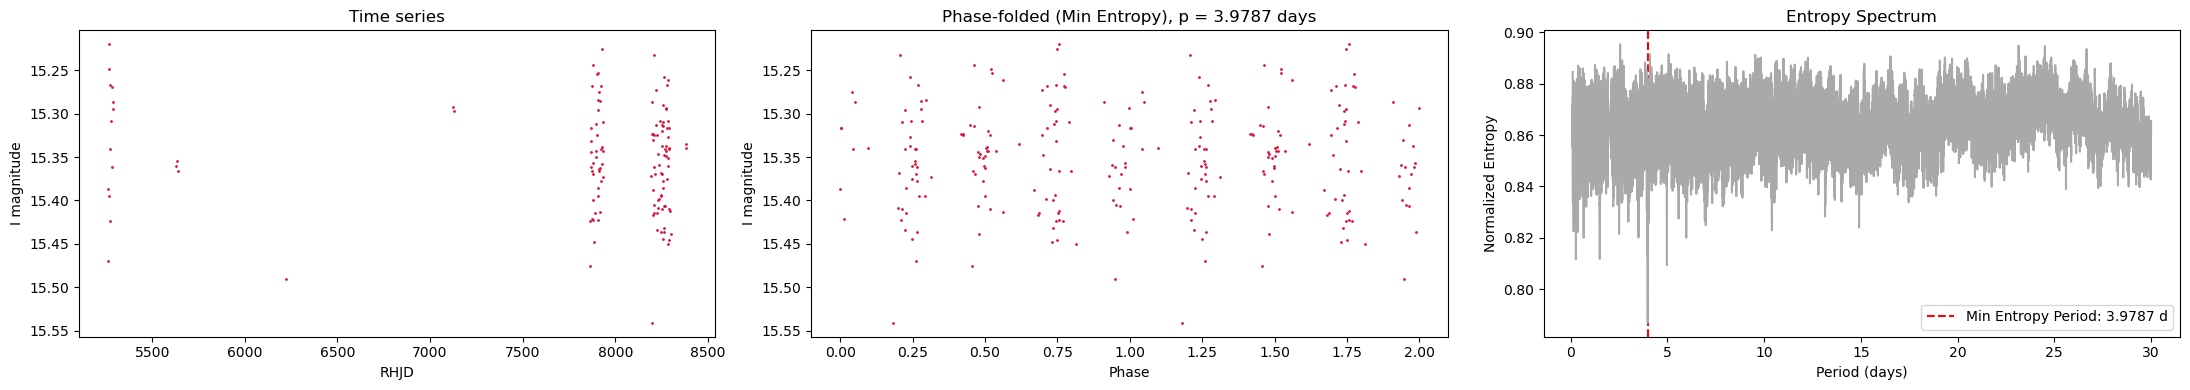

Procesando estrella 10/20: 09...


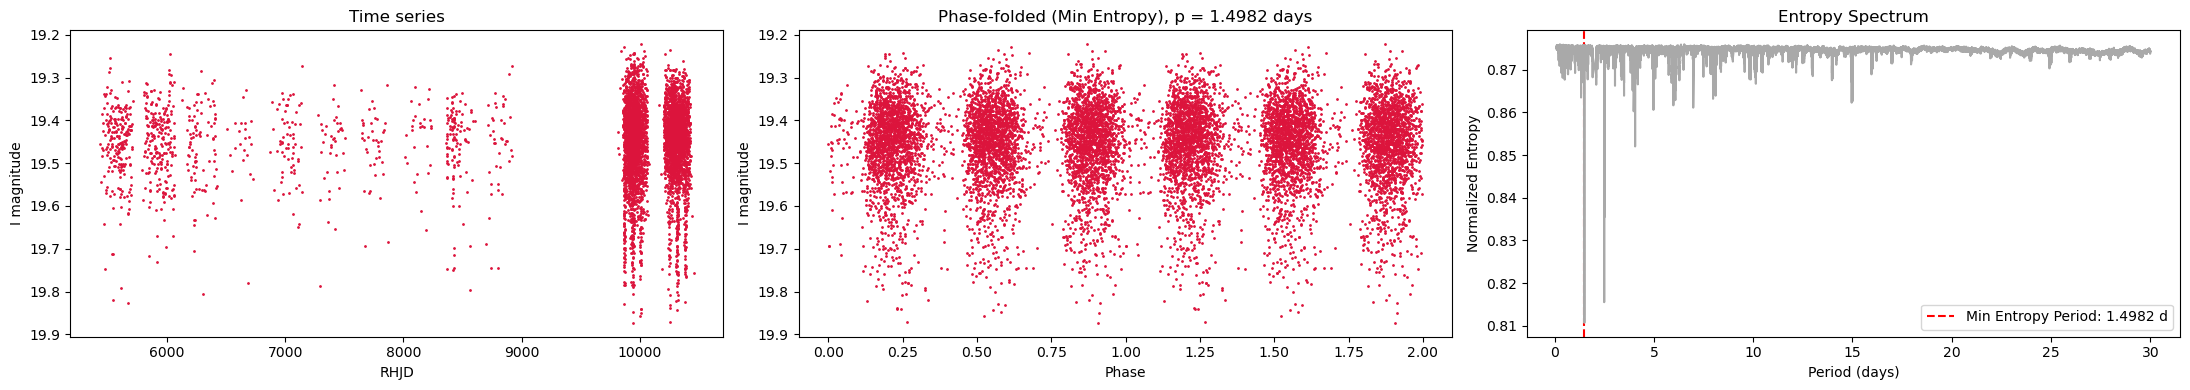

Procesando estrella 11/20: 0a...


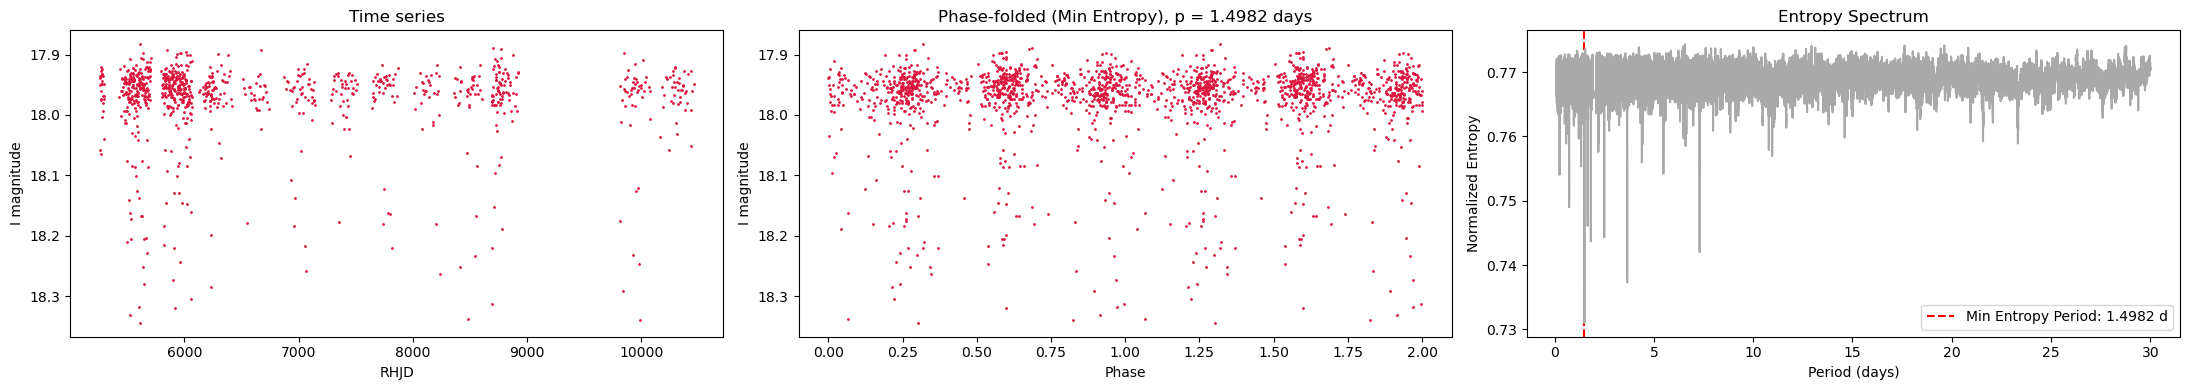

Procesando estrella 12/20: 0b...


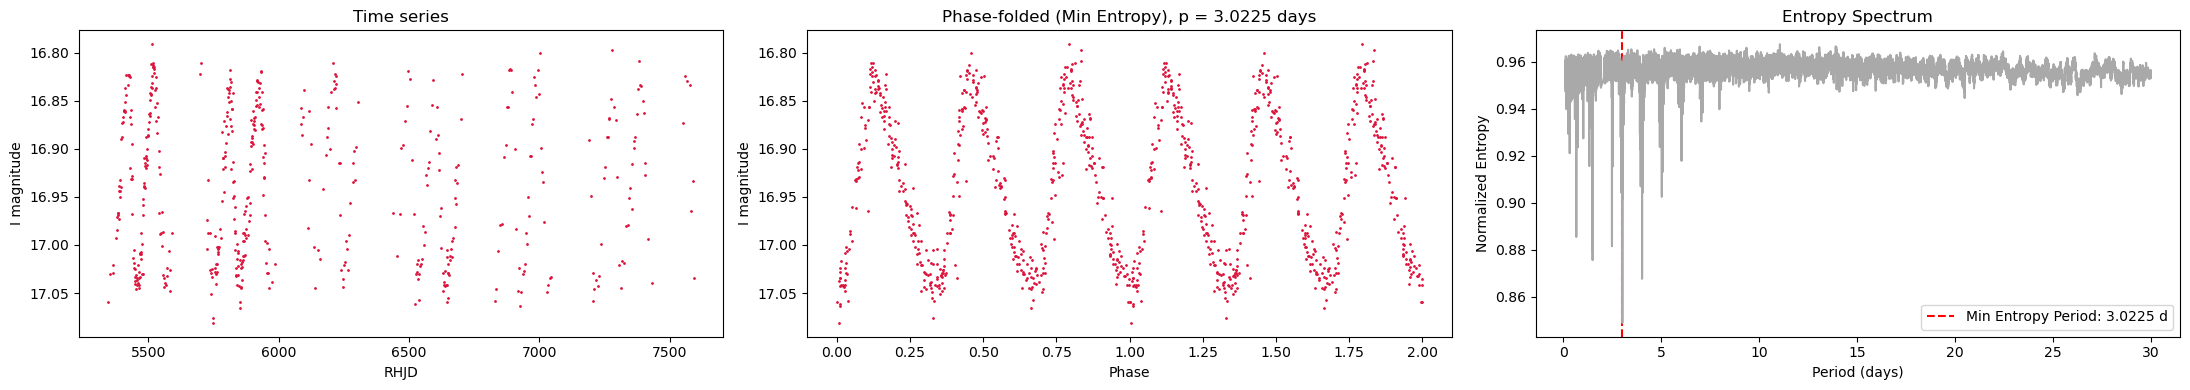

Procesando estrella 13/20: 0c...


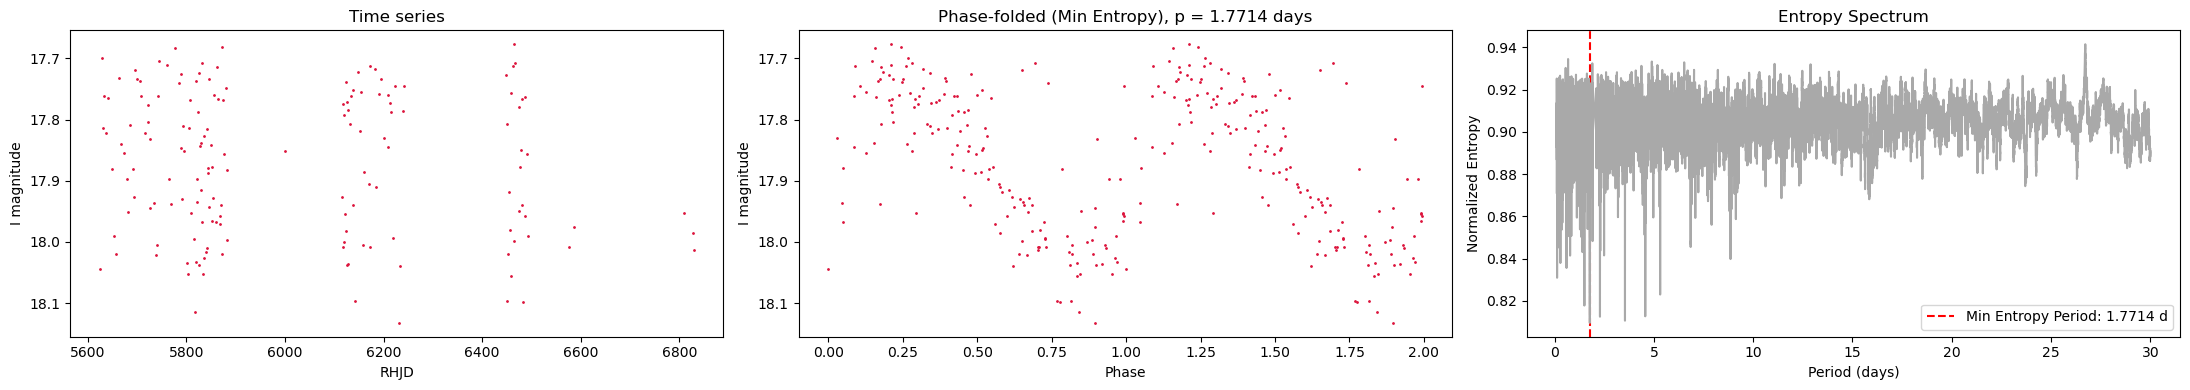

Procesando estrella 14/20: 0d...


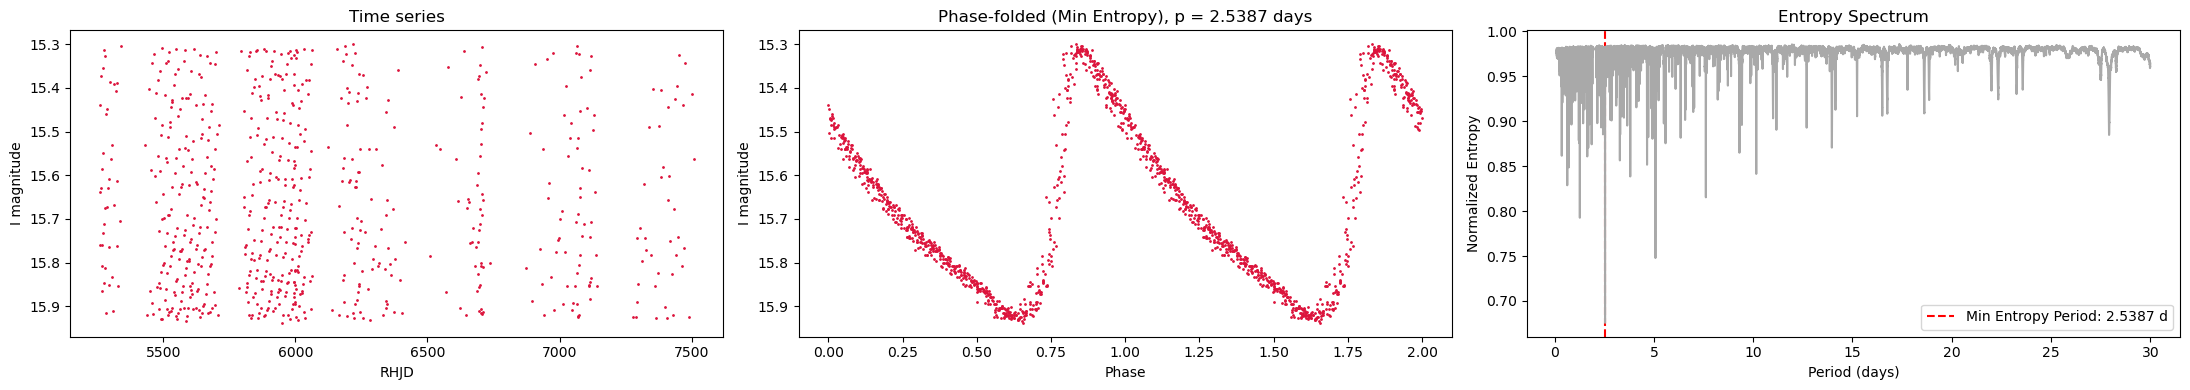

Procesando estrella 15/20: 0e...


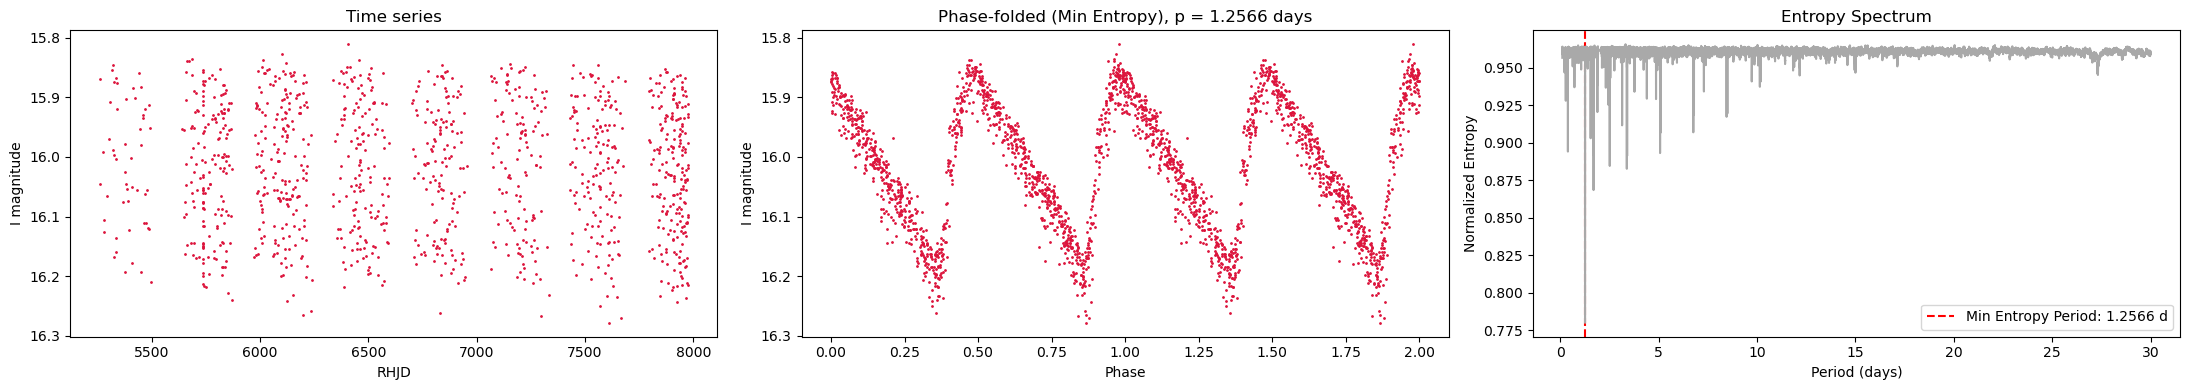

Procesando estrella 16/20: 0f...


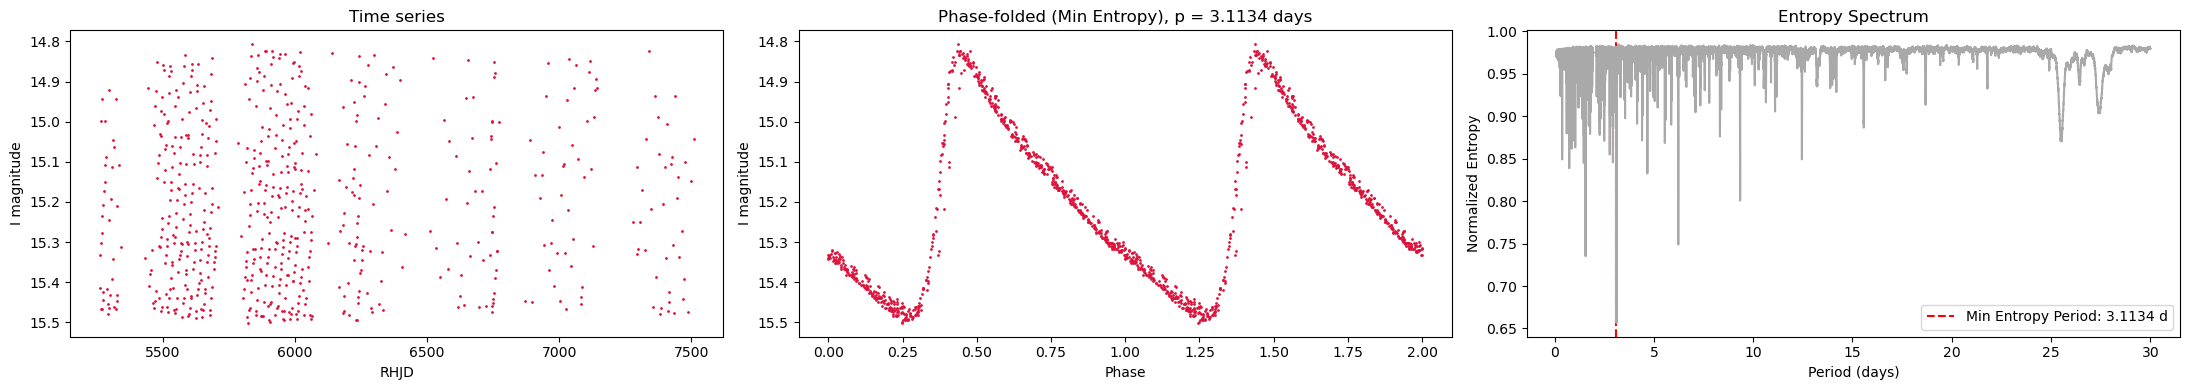

Procesando estrella 17/20: 10...


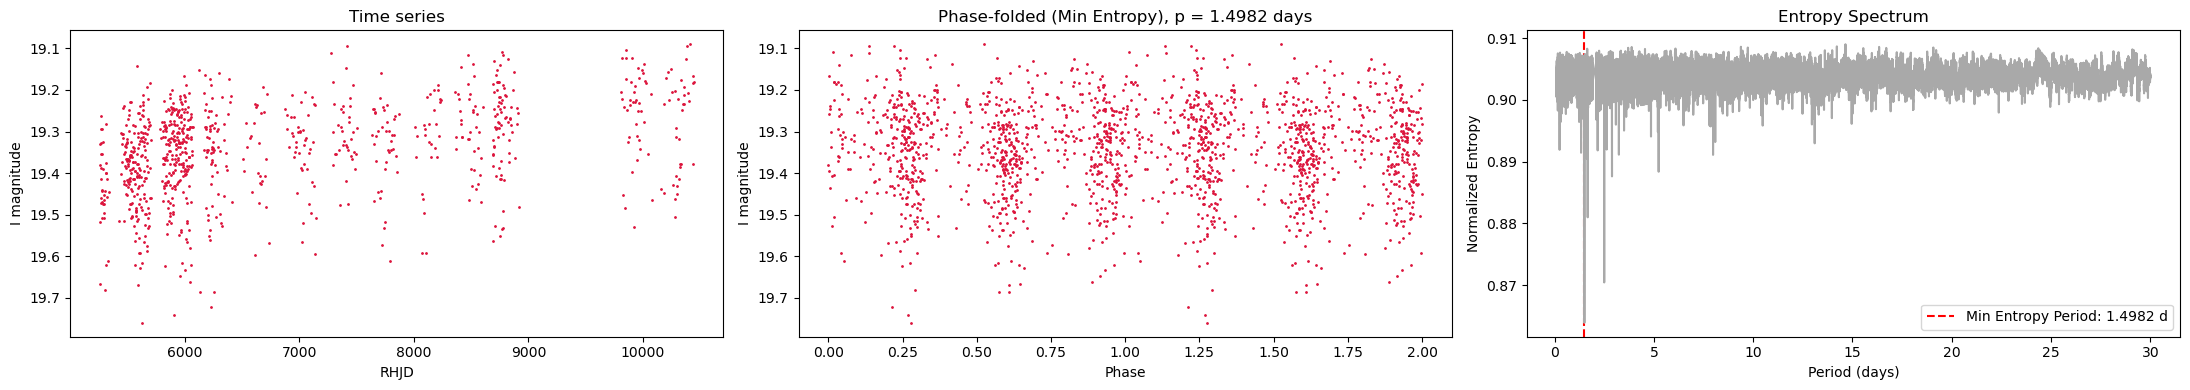

Procesando estrella 18/20: 11...


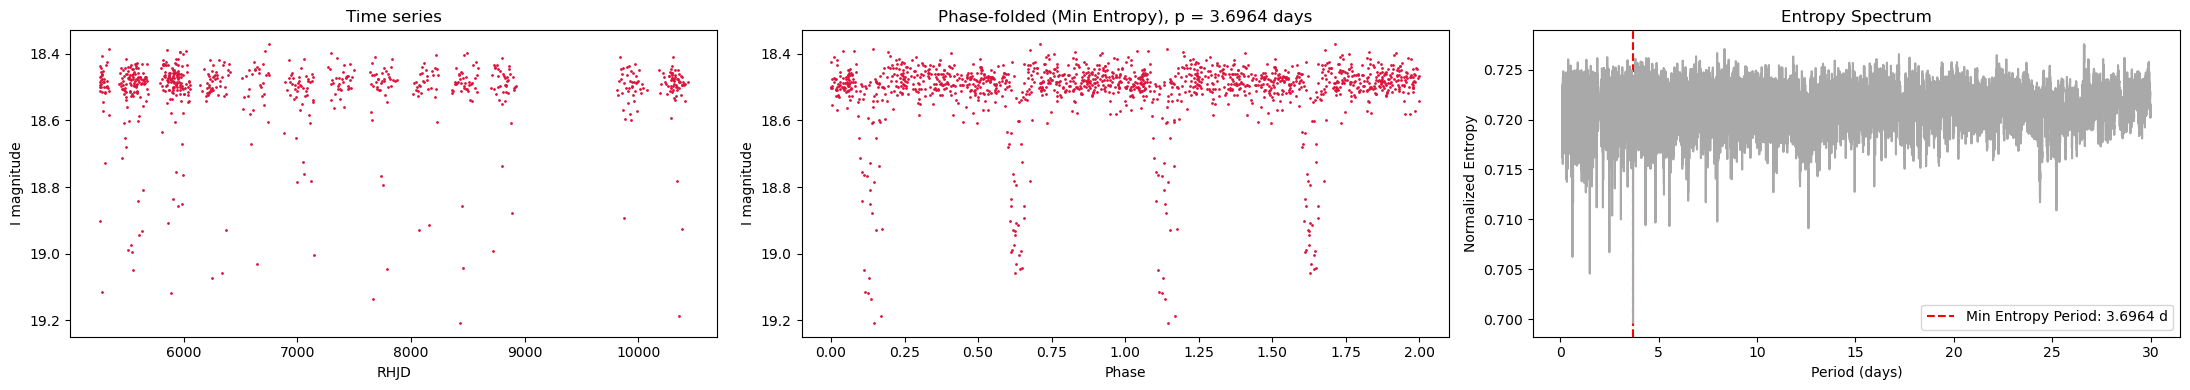

Procesando estrella 19/20: 12...


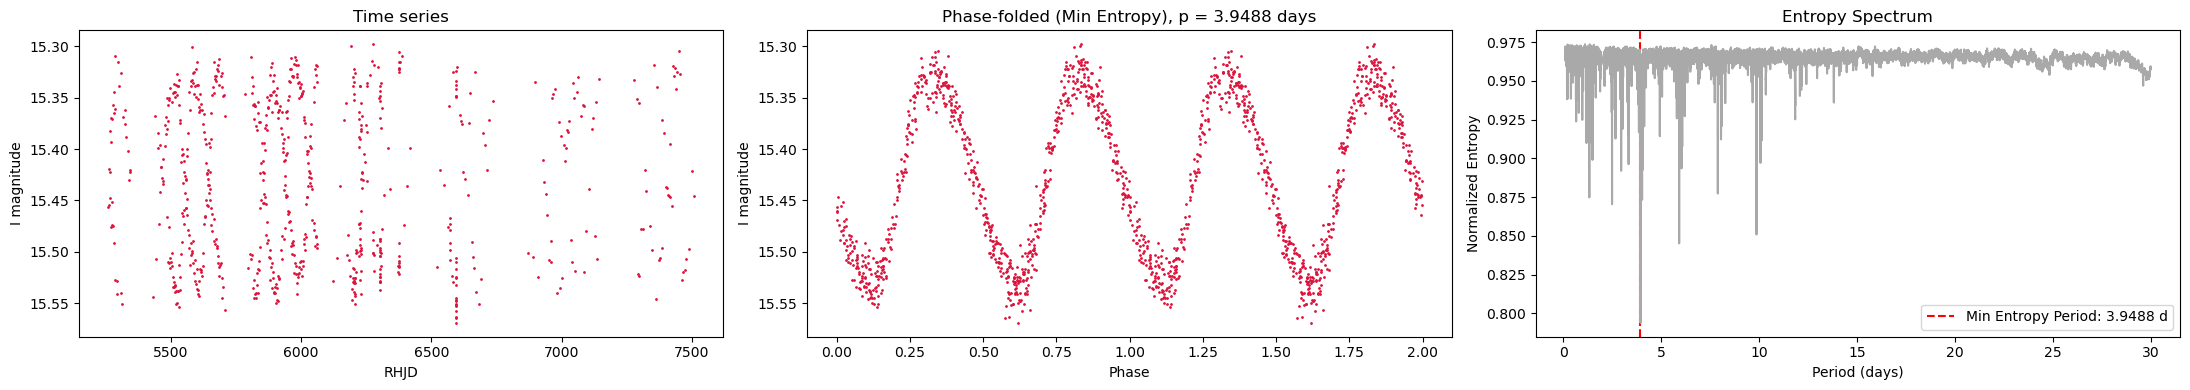

Procesando estrella 20/20: 13...


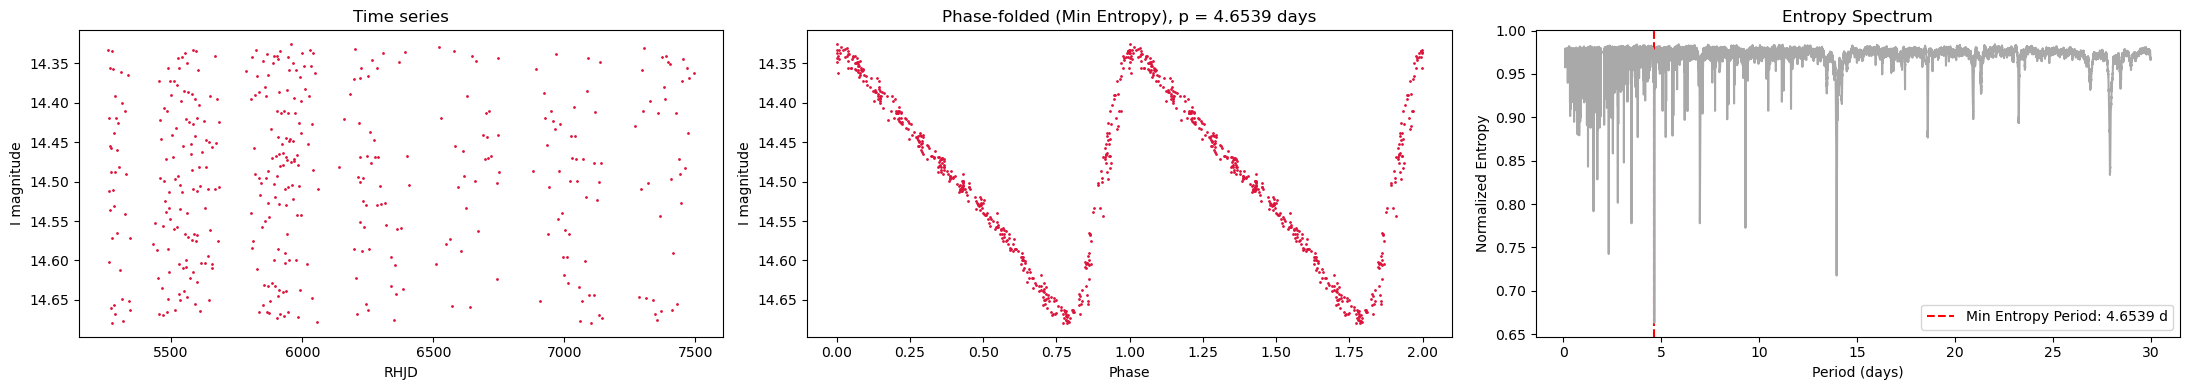

¡Procesamiento de Mínima Entropía completado!


In [ ]:
#Minima Entropía
def _safe_norm(x):
    x_mean, x_std = np.mean(x), np.std(x)
    if x_std == 0:
        return np.zeros_like(x)
    return (x - x_mean) / x_std

def calculate_entropy(phi_norm, mag_norm, m):
    hist, _, _ = np.histogram2d(phi_norm, mag_norm, bins=(m, m))
    count = hist.flatten()
    mu = (count / len(phi_norm)) + 1e-10 
    
    # Calculate Shannon Entropy (S = -sum(mu * log(mu)))
    s = -np.sum(mu * np.log(mu))
    
    # Normalize by the maximum possible entropy (log(m*m))
    return s / np.log(m * m)

def periodogram_entropy(mjd, mag_norm, periods, m):
    entropies = np.empty(len(periods), dtype=float)
    
    for i, p in enumerate(periods):
        phi = phase_folding(p, mjd)
        phi_norm = _safe_norm(phi)
        entropies[i] = calculate_entropy(phi_norm, mag_norm, m)
        
    return entropies

periodo_prueba = np.linspace(0.1, 30, 50000)

frecuencias = 1.0 / periodo_prueba

atol_val = 0.02 

es_alias_entero = np.any([np.isclose(periodo_prueba, i, atol=atol_val) for i in range(1, 10)], axis=0)

es_alias_fraccional = np.any([np.isclose(frecuencias, 1/frac, atol=atol_val) for frac in [0.5, 2.0]], axis=0)

mascara_segura = ~(es_alias_entero | es_alias_fraccional)

periodo_prueba_limpio = periodo_prueba[mascara_segura]

print(f"Puntos originales: {len(periodo_prueba)}. Puntos tras limpiar alias: {len(periodo_prueba_limpio)}")

with h5py.File(db, "r") as file:
    star_codes = list(file["/"].keys())
    
    estrellas_a_procesar = star_codes[:20]
    
    for i, name in enumerate(estrellas_a_procesar):
        print(f"Procesando estrella {i+1}/20: {name}...")
        

        star_data = pd.DataFrame(file[name][:])
        mjd = star_data.RHJD
        mag = star_data.mag
        
        mag_norm = _safe_norm(mag)
        entropies = periodogram_entropy(mjd, mag_norm, periodo_prueba_limpio, m=10)
        period_min_entropy = periodo_prueba_limpio[np.argmin(entropies)]
        phase = phase_folding(period_min_entropy, mjd)

        plt.figure(figsize=(22, 4))

        plt.subplot(1, 3, 1)
        plt.scatter(mjd, mag, c='crimson', s=1)
        plt.gca().invert_yaxis()
        plt.title(f"Time series")
        plt.xlabel("RHJD")
        plt.ylabel("I magnitude")
        
        plt.subplot(1, 3, 2)
        plt.scatter(phase, mag, c='crimson', s=1)
        plt.scatter(phase + 1, mag, c='crimson', s=1)
        plt.gca().invert_yaxis()
        plt.title(f"Phase-folded (Min Entropy), p = {period_min_entropy:.4f} days")
        plt.xlabel("Phase")
        plt.ylabel("I magnitude")
        
        plt.subplot(1, 3, 3)
        plt.plot(periodo_prueba_limpio, entropies, color='darkgray')
        
        plt.axvline(period_min_entropy, color='red', linestyle='--', 
                    label=f'Min Entropy Period: {period_min_entropy:.4f} d', zorder=-10)
        
        plt.legend()
        plt.xlabel('Period (days)')
        plt.ylabel('Normalized Entropy')
        plt.title('Entropy Spectrum')
        
        plt.tight_layout()
        
        plt.show() 
        
        plt.close()


